# Group Project (Part 1 + Part 2): Data Quality Report and Data Quality Plan

This notebook is a clean, structured version of your Part 1 + Part 2 workflow for:
- **Part 1 (DQR):** data understanding + initial cleaning on training data only
- **Part 2 (DQP):** feature-by-feature plan + implemented cleaning decisions

Dataset used:
- `ppr-group-22312913-train.csv` only

Target feature:
- `Price (€)`

Before running this notebook make sure the run the following commands in your terminal to download the required packages:
- python3 -m venv .venv
- source .venv/bin/activate
- pip install -r requirements.txt


## Notebook Roadmap

Note - everything will be done with functions so that it is easy to reproduce on test and train datasets.

1. Load and inspect raw training data
2. Convert feature types for analysis
3. Run core quality checks (missingness, duplicates, constants)
4. Test and validate the Eircode routing-key strategy (first 3 characters)
5. Produce DQR tables and focused visualisations
6. Write and implement the DQP (final cleaning decisions)
7. Validate final dataset (no NaN values) and export files


In [32]:
import warnings
warnings.filterwarnings('ignore')

import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


try:
    import seaborn as sns
    sns.set_style('whitegrid')
    USE_SEABORN = True
except Exception:
    USE_SEABORN = False

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

## Step 1: Load Dataset and Basic Inspection

This step confirms the dataset dimensions, feature names, and raw types.


In [33]:
# Create a funciton to load and display basic info about the raw train data.
# Here we will also be adding raw_id for traceability.
def load_and_inspect_dataset(train_path, delete_dup = True):
    df_raw = pd.read_csv(train_path)

    # Raw transaction signature columns (used for dedup before feature reductions)
    RAW_FEATURE_COLS = [
        'Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (€)',
        'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description'
    ]

    # Add stable row id for traceability
    df_raw = df_raw.reset_index(drop=True)
    df_raw['row_id'] = df_raw.index + 1

    print('Raw train shape (before raw-signature dedup):', df_raw.shape)

    if delete_dup:
        # Count and remove exact raw-signature duplicates once
        raw_dup_count = int(df_raw.duplicated(subset=RAW_FEATURE_COLS).sum())
        print('Raw duplicate rows on full transaction signature:', raw_dup_count)
        df_raw = df_raw.drop_duplicates(subset=RAW_FEATURE_COLS, keep='first').copy()
        print('Raw train shape (after raw-signature dedup):', df_raw.shape)

    print('\nColumns:')
    print(df_raw.columns.tolist())
    print('\nRaw dtypes:')
    print(df_raw.dtypes)

    display(df_raw.head(5))

    return df_raw


## Step 2: Reusable Data-Quality Helpers

These helper functions are used repeatedly for DQR summaries and checks. 


In [34]:
def quality_overview(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing_count': df.isna().sum(),
        'missing_%': (df.isna().mean() * 100).round(2),
        'nunique_including_nan': df.nunique(dropna=False),
    })
    return out.sort_values(['missing_%', 'nunique_including_nan'], ascending=[False, False])


def numeric_summary(df: pd.DataFrame) -> pd.DataFrame:
    cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if not cols:
        return pd.DataFrame()
    return df[cols].describe().T


def categorical_summary(df: pd.DataFrame) -> pd.DataFrame:
    cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    if not cols:
        return pd.DataFrame()
    return df[cols].describe().T

# Some other functions that are useful for cleaning and feature engineering.
# Clean and standardise string columns (e.g. for address matching and routing key inference).
def string_cleaner(s: pd.Series) -> pd.Series:
    return (
        s.astype('string')
        .str.upper()
        .str.replace(r'[^A-Z0-9]+', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

# Define the main function to run all quality checks and display the results in a table.
DATE_COL='Date of Sale (dd/mm/yyyy)'
PRICE_COL='Price (€)'

## Step 3: Type Conversion for DQR Analysis

Decisions in this stage:
- Parse `Date of Sale (dd/mm/yyyy)` into datetime
- Parse `Price (€)` into numeric euro values
- Cast low-cardinality fields to `category`
- Keep `Address` as free text (high cardinality)


In [35]:
def clean_and_cast_dtypes(df_raw):
    df_dqr = df_raw.copy()
    # Parse date
    DATE_COL = 'Date of Sale (dd/mm/yyyy)'
    df_dqr[DATE_COL] = pd.to_datetime(df_dqr[DATE_COL], format='%d/%m/%Y', errors='coerce')

    # Parse price
    PRICE_COL = 'Price (€)'
    df_dqr[PRICE_COL] = (
        df_dqr[PRICE_COL]
        .astype('string')
        .str.replace('€', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    df_dqr[PRICE_COL] = pd.to_numeric(df_dqr[PRICE_COL], errors='coerce')

    # Cast categories
    category_cols = [
        'County',
        'Eircode',
        'Not Full Market Price',
        'VAT Exclusive',
        'Description of Property',
        'Property Size Description',
    ]
    for col in category_cols:
        df_dqr[col] = df_dqr[col].astype('category')

    # Address kept as text
    df_dqr['Address'] = df_dqr['Address'].astype('string').str.strip()

    print('Converted dtypes:')
    print(df_dqr.dtypes)

    return df_dqr

## Step 4: Core Quality Checks (Raw + Converted)

This captures the basic quality profile expected in Part 1.


In [36]:
def run_quality_checks(df_dqr):
    constant_cols = [c for c in df_dqr.columns if df_dqr[c].nunique(dropna=False) <= 1]
    print('Constant columns:', constant_cols)

    print('\nQuality overview:')
    display(quality_overview(df_dqr))

    print('\nPrice quick checks:')
    print('Missing prices:', int(df_dqr[PRICE_COL].isna().sum()))
    print('Min price:', float(df_dqr[PRICE_COL].min()))
    print('Max price:', float(df_dqr[PRICE_COL].max()))

    print('\nDate quick checks:')
    print('Missing dates:', int(df_dqr[DATE_COL].isna().sum()))
    print('Min date:', df_dqr[DATE_COL].min())
    print('Max date:', df_dqr[DATE_COL].max())


## Step 5.1: Eircode Strategy - Routing Key (First 3 Characters)

Your method is preserved and formalised:
1. Convert full Eircode to routing key (first 3 chars)
2. Infer routing key from `Address + County` using a routing reference table
3. Validate inference error on rows where true routing key is known
4. Fill missing routing keys only where inference exists

This gives a reproducible and explainable alternative to external APIs.


In [37]:
def area_code_inference(df_dqr, DATE_COL='Date of Sale (dd/mm/yyyy)'):
    # Time helpers for trend analysis
    df_dqr['Year'] = df_dqr[DATE_COL].dt.year
    df_dqr['Month'] = df_dqr[DATE_COL].dt.month

    # Original routing key (from existing Eircode)
    df_dqr['Eircode_Routing'] = df_dqr['Eircode'].astype('string').str[:3].str.upper()

    missing_eircode_full = df_dqr['Eircode'].isna().mean() * 100
    missing_routing = df_dqr['Eircode_Routing'].isna().mean() * 100

    print(f'Missing full Eircode before inference: {missing_eircode_full:.2f}%')
    print(f'Missing routing key before inference: {missing_routing:.2f}%')

    print('\nEircode missing % by year (full code):')
    year_missing = df_dqr.groupby('Year')['Eircode'].apply(lambda s: s.isna().mean() * 100)
    display(year_missing.round(2))

    routing_text = """
    A92,Ardee,Louth
    Y14,Arklow,Wicklow
    A84,Ashbourne,Meath
    H65,Athenry,Galway
    N37,Athlone,Westmeath
    R14,Athy,Kildare
    K32,Balbriggan,Dublin
    F26,Ballina,Mayo
    H53,Ballinasloe,Galway
    P31,Ballincollig,Cork
    F31,Ballinrobe,Mayo
    A75,Ballybay,Monaghan
    A41,Ballyboughal,Dublin
    F35,Ballyhaunis,Mayo
    F56,Ballymote,Sligo
    P72,Bandon,Cork
    P75,Bantry,Cork
    H14,Belturbet,Cavan
    R42,Birr,Offaly
    A94,Blackrock,Dublin
    F52,Boyle,Roscommon
    A98,Bray,Wicklow
    V23,Caherciveen,Kerry
    E21,Cahir,Tipperary
    A81,Carrickmacross,Monaghan
    N41,Carrick-on-Shannon,Leitrim
    E32,Carrick-on-Suir,Tipperary
    P43,Carrigaline,Cork
    E25,Cashel,Tipperary
    F23,Castlebar,Mayo
    A75,Castleblaney,Monaghan
    F45,Castlerea,Roscommon
    P56,Charleville,Cork
    F12,Claremorris,Mayo
    H71,Clifden,Galway
    P85,Clonakilty,Cork
    H23,Clones,Monaghan
    E91,Clonmel,Tipperary
    P24,Cobh,Cork
    H16,Cootehill,Cavan
    T12,Cork (centre and southside),Cork
    T23,Cork (northside),Cork
    P14,Crookstown,Cork
    P32,Donoughmore,Cork
    P47,Dunmanway,Cork
    T56,Watergrasshill,Cork
    T34,Whitechurch,Cork
    R56,Curragh Camp,Kildare
    A63,Delgany,Wicklow
    A92,Drogheda,Louth
    D01,Dublin 1,Dublin
    D02,Dublin 2,Dublin
    D03,Dublin 3,Dublin
    D04,Dublin 4,Dublin
    D05,Dublin 5,Dublin
    D06,Dublin 6,Dublin
    D6W,Dublin 6W,Dublin
    D07,Dublin 7,Dublin
    D08,Dublin 8,Dublin
    D09,Dublin 9,Dublin
    D10,Dublin 10,Dublin
    D11,Dublin 11,Dublin
    D12,Dublin 12,Dublin
    D13,Dublin 13,Dublin
    D14,Dublin 14,Dublin
    D15,Dublin 15,Dublin
    D16,Dublin 16,Dublin
    D17,Dublin 17,Dublin
    D18,Dublin 18,Dublin
    D20,Dublin 20,Dublin
    D22,Dublin 22,Dublin
    D24,Dublin 24,Dublin
    A86,Dunboyne,Meath
    A91,Dundalk,Louth
    X35,Dungarvan,Waterford
    A85,Dunshaughlin,Meath
    R45,Edenderry,Offaly
    A83,Enfield,Meath
    V95,Ennis,Clare
    Y21,Enniscorthy,Wexford
    P61,Fermoy,Cork
    H91,Galway,Galway
    A42,Garristown,Dublin
    A96,Glenageary,Dublin
    Y25,Gorey,Wexford
    A63,Greystones,Wicklow
    A82,Kells,Meath
    A63,Kilcoole,Wicklow
    V93,Killarney,Kerry
    X42,Kilmacthomas,Waterford
    V35,Kilmallock,Limerick
    V15,Kilrush,Clare
    A82,Kingscourt,Cavan
    P17,Kinsale,Cork
    A92,Laytown-Bettystown-Mornington,Meath
    F92,Letterkenny,Donegal
    F93,Lifford,Donegal
    V94,Limerick,Limerick
    V31,Listowel,Kerry
    T45,Little Island,Cork
    N39,Longford,Longford
    H62,Loughrea,Galway
    K78,Lucan,Dublin
    K45,Lusk,Dublin
    P12,Macroom,Cork
    K36,Malahide,Dublin
    P51,Mallow,Cork
    W23,Maynooth,Kildare
    P25,Midleton,Cork
    P67,Mitchelstown,Cork
    W34,Monasterevin,Kildare
    A94,Monkstown,Dublin
    R21,Muine Bheag,Carlow
    N91,Mullingar,Westmeath
    W91,Naas,Kildare
    C15,Navan,Meath
    E45,Nenagh,Tipperary
    Y34,New Ross,Wexford
    W12,Newbridge,Kildare
    A63,Newcastle,Wicklow
    V42,Newcastle West,Limerick
    A63,Newtownmountkennedy,Wicklow
    A45,Portlaoise,Laois
    A67,Rathnew,Wicklow
    A85,Ratoath,Meath
    E53,Roscrea,Tipperary
    K56,Rush,Dublin
    V14,Shannon,Clare
    K34,Skerries,Dublin
    P81,Skibbereen,Cork
    A83,Summerhill,Meath
    K67,Swords,Dublin
    E41,Thurles,Tipperary
    V92,Tralee,Kerry
    H54,Tuam,Galway
    R32,Portlaoise,Laois
    R35,Tullamore,Offaly
    A82,Virginia,Cavan
    X91,Waterford,Waterford
    F28,Westport,Mayo
    P36,Youghal,Cork
    """

    # Excluded because of high mistake rate. With these the data was filled in up to 26% at 10% mistake rate.
    # Can be tested out by inputting the below routing keys and re-running the routing key inference.
    # I have excluded only counties that had 10% and more mistake rate.
    # F42,Roscommon,Roscommon
    # F94,Donegal,Donegal
    # R51,Kildare,Kildare
    # H12,Cavan,Cavan
    # R95,Kilkenny,Kilkenny
    # F91,Sligo,Sligo
    # E34,Tipperary,Tipperary
    # A67,Wicklow,Wicklow
    # Y35,Wexford,Wexford
    # R93,Carlow,Carlow
    # H18,Monaghan,Monaghan


    routing_reference = pd.read_csv(
        io.StringIO(routing_text),
        sep=',',
        header=None,
        names=['Eircode3', 'Town', 'County'],
    )

    for col in ['Eircode3', 'Town', 'County']:
        routing_reference[col] = routing_reference[col].astype('string').str.strip()

    # Build a safe routing-key-to-county lookup for Step 8.
    # We only keep routing keys that map to exactly one county in the reference table.
    # Ambiguous routing keys such as A82 and A92 are excluded from this lookup
    # so that Step 8 does not overwrite counties incorrectly.
    area_county_all = (
        routing_reference[['Eircode3', 'County']]
        .dropna()
        .drop_duplicates()
        .copy()
    )

    county_counts = (
        area_county_all.groupby('Eircode3')['County']
        .nunique()
    )

    unique_area_county = (
        area_county_all[
            area_county_all['Eircode3'].map(county_counts) == 1
        ]
        .reset_index(drop=True)
    )

    ambiguous_area_codes = county_counts[county_counts > 1].index.tolist()

    # Save the safe lookup for Step 8.
    area_code_inference.unique_area_county_reference_ = unique_area_county
    area_code_inference.ambiguous_area_codes_ = ambiguous_area_codes

    print('Unique routing-key county lookup rows:', len(unique_area_county))
    print('Ambiguous routing keys excluded from Step 8 county overwrite:', ambiguous_area_codes)

    # Add cleaned uppercase Town column for matching
    routing_reference['Town_up'] = string_cleaner(routing_reference['Town'])

    # Here we separate the rows where the town and county are the same, as these are likely to be less reliable for matching, and we can use them to fill in the routing keys for the rest of the dataset.
    routing_df2 = routing_reference[routing_reference['Town'] == routing_reference['County']].copy()
    routing_df = routing_reference[routing_reference['Town'] != routing_reference['County']].copy()

    print('Routing reference rows:', len(routing_df))

    # Clean address for matching
    df_dqr['Address_clean'] = string_cleaner(df_dqr['Address'])

    # Inferred routing key candidate (from address + county (Where address town cannot have the same name as the county))
    df_dqr['Eircode_Routing_Inferred'] = pd.NA

    town_to_code = routing_df.set_index('Town_up')['Eircode3'].to_dict()
    town_to_county = routing_df.set_index('Town_up')['County'].to_dict()

    for town, code in town_to_code.items():
        cnty = town_to_county[town]
        town_re = rf'\b{re.escape(town)}\b'
        hit = df_dqr['Address_clean'].str.contains(town_re, na=False)
        county_match = df_dqr['County'].astype('string') == cnty
        empty_target = df_dqr['Eircode_Routing_Inferred'].isna()
        df_dqr.loc[empty_target & hit & county_match, 'Eircode_Routing_Inferred'] = code

    # Numbers filled in after first clean
    first_clean = int(df_dqr['Eircode_Routing_Inferred'].notna().sum())

    print('Rows with inferred routing key:', first_clean)


    # Now using routing_df2 to infer routing keys for cases where town and county are the same (e.g. Galway, Galway).
    # Here, we already filled out most addresses, so now whatever hasn't been filled in.
    # These cases we can check if the town name appears in the address and if the county matches, then we can infer the routing key as well.
    town_to_code2 = routing_df2.set_index('Town_up')['Eircode3'].to_dict()
    town_to_county2 = routing_df2.set_index('Town_up')['County'].to_dict()

    # Making sure to check that it only works on the values that haven't been filled in by the first pass, to avoid false positives (e.g. Galway town name appearing in an address in Galway county, but the actual town is different and already matched by the first pass).
    for town, code in town_to_code2.items():
        cnty = town_to_county2[town]
        town_re = rf'\b{re.escape(town)}\b'
        hit = df_dqr['Address_clean'].str.contains(town_re, na=False)
        county_match = df_dqr['County'].astype('string') == cnty
        empty_target = df_dqr['Eircode_Routing_Inferred'].isna()
        df_dqr.loc[empty_target & hit & county_match, 'Eircode_Routing_Inferred'] = code

    # Numbers filled in after second clean
    second_clean = int(df_dqr['Eircode_Routing_Inferred'].notna().sum())

    print('Rows with inferred routing key after second pass:', second_clean - first_clean)

    # Validation: compare inferred routing key with true routing key where both are available

    m = df_dqr['Eircode_Routing_Inferred'].notna() & df_dqr['Eircode_Routing'].notna()
    compared_rows = int(m.sum())
    errors = int((df_dqr.loc[m, 'Eircode_Routing_Inferred'] != df_dqr.loc[m, 'Eircode_Routing']).sum())
    error_rate = (errors / compared_rows * 100) if compared_rows else np.nan

    print('Compared rows:', compared_rows)
    print('Match rows:', compared_rows - errors)
    print('Mismatch rows:', errors)
    print(f'Error rate: {error_rate:.2f}%')

    mismatch_df = df_dqr.loc[m & (df_dqr['Eircode_Routing_Inferred'] != df_dqr['Eircode_Routing'])].copy()

    print('\nTop mismatch counties:')
    display(mismatch_df['County'].value_counts().head(10))

    print('\nMismatches by year:')
    display(mismatch_df['Year'].value_counts().sort_index())

    # Here i wanted to see which counties in specific has the largest number of mismatches and error rates.
    # Realistically anything above 10% error rate would be a red flag.
    # So excluding the first 11 counties with the most mismatches (to make it <10% mismatch rate for counties).
    # Specifically Town Name == County. 

    county_compared = df_dqr.loc[m, 'County'].value_counts()
    county_mismatches = mismatch_df['County'].value_counts()

    county_summary = pd.DataFrame({
        'compared_rows': county_compared,
        'mismatch_rows': county_mismatches
    }).fillna(0)

    county_summary['mismatch_rows'] = county_summary['mismatch_rows'].astype(int)
    county_summary['match_rows'] = county_summary['compared_rows'] - county_summary['mismatch_rows']
    county_summary['error_rate_%'] = (
        county_summary['mismatch_rows'] / county_summary['compared_rows'] * 100
    ).round(2)

    county_summary = county_summary.sort_values(
        ['error_rate_%', 'mismatch_rows'],
        ascending=[False, False]
    )

    display(county_summary.head(15))

    # Apply inference only where routing key is missing

    missing_before = df_dqr['Eircode_Routing'].isna().mean() * 100
    fill_mask = df_dqr['Eircode_Routing'].isna() & df_dqr['Eircode_Routing_Inferred'].notna()
    df_dqr.loc[fill_mask, 'Eircode_Routing'] = df_dqr.loc[fill_mask, 'Eircode_Routing_Inferred']
    missing_after = df_dqr['Eircode_Routing'].isna().mean() * 100

    print(f'Routing-key missing before fill: {missing_before:.2f}%')
    print(f'Routing-key missing after fill : {missing_after:.2f}%')

    table = (
        df_dqr.assign(missing_eircode=df_dqr["Eircode_Routing"].isna())
        .groupby(["Year", "County"])["missing_eircode"]
        .mean()
        .mul(100)
        .round(1)
        .unstack()
    )

    print(table)
    return df_dqr

## Step 5.2: Description of Property.

Method is preserved and formalised:
1. First check the different count of unique objects.
2. Figure out that Teach/Arasan Conaithe Athaimhe in Irish means Refurbished (2nd hand).
3. With only 2 values it makes sense to convert it to just second hand dwelling.
4. Make it a Boolean column yes or no for second hand.

This gives a reproducible.

In [38]:
# Now we will do the second hand inference based on the "Description of Property" column. 
# We will create a new binary column "Is_Second_Hand" which will be 1 if the property is second hand and 0 if it is new. 
# We will also check the value counts of the "Description of Property" column to see how many properties are second hand and how many are new.
def second_hand_inference(df_dqr):
    display(df_dqr['Description of Property'].value_counts(dropna=False))

    df_dqr["Description of Property"] = df_dqr["Description of Property"].replace(
        "Teach/Árasán Cónaithe Atháimhe",
        "Second-Hand Dwelling house /Apartment"
    )

    display(df_dqr['Description of Property'].value_counts(dropna=False))

    df_dqr['Is_Second_Hand'] = df_dqr['Description of Property'].str.lower().eq('second-hand dwelling house /apartment')
    df_dqr['Is_Second_Hand'] = df_dqr['Is_Second_Hand'].map({True: 1, False: 0})

    display(df_dqr['Is_Second_Hand'].value_counts(dropna=False))
    display(df_dqr[['Description of Property','Is_Second_Hand']].head(10))
    return df_dqr

## Step 6: Statistical show

In [39]:
def statistical_report(
    df,
    price_col='Price (€)',
    date_col='Date of Sale (dd/mm/yyyy)',
    county_col='County',
    address_col='Address',
    area_col='Eircode_Routing',
):
    out = df.copy()

    out[price_col] = pd.to_numeric(out[price_col], errors='coerce')
    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')
    out = out.dropna(subset=[price_col, date_col]).copy()

    out['log_price'] = np.log1p(out[price_col])

    price_percentiles = out[price_col].quantile([0.90, 0.95, 0.99, 0.995, 0.999])
    p995 = price_percentiles.loc[0.995]
    p999 = price_percentiles.loc[0.999]

    out['above_99_5pct'] = (out[price_col] >= p995).astype('int8')
    out['is_extreme_price'] = (out[price_col] >= p999).astype('int8')

    out['sale_year'] = out[date_col].dt.year
    out['sale_month'] = out[date_col].dt.month
    out['sale_period'] = out[date_col].dt.to_period('M')
    out['sale_month_start'] = out['sale_period'].dt.to_timestamp()

    out['county_clean'] = out[county_col].fillna('Unknown').astype('string').str.strip()

    if area_col in out.columns:
        out['area_code_clean'] = (
            out[area_col]
            .fillna('Unknown')
            .astype('string')
            .str.upper()
            .str.strip()
        )
    else:
        out['area_code_clean'] = 'Unknown'

    out['area_code_missing'] = out['area_code_clean'].eq('UNKNOWN').astype('int8')
    out['address_text'] = out[address_col].astype('string').str.strip()

    target_stats = pd.DataFrame(
        {
            'price': out[price_col].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]),
            'log_price': out['log_price'].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]),
        }
    )
    display(target_stats)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    if USE_SEABORN:
        sns.histplot(out[price_col], bins=60, ax=axes[0, 0], color='#4C78A8')
        sns.histplot(out['log_price'], bins=60, ax=axes[0, 1], color='#F58518')
        sns.boxplot(x=out[price_col], ax=axes[1, 0], color='#72B7B2')
        sns.boxplot(x=out['log_price'], ax=axes[1, 1], color='#E45756')
    else:
        axes[0, 0].hist(out[price_col].dropna(), bins=60, color='#4C78A8')
        axes[0, 1].hist(out['log_price'].dropna(), bins=60, color='#F58518')
        axes[1, 0].boxplot(out[price_col].dropna(), vert=False)
        axes[1, 1].boxplot(out['log_price'].dropna(), vert=False)

    axes[0, 0].set_title('Histogram of raw price')
    axes[0, 0].set_xlabel('Price (€)')

    axes[0, 1].set_title('Histogram of log price')
    axes[0, 1].set_xlabel('log1p(price)')

    axes[1, 0].set_title('Boxplot of raw price')
    axes[1, 0].set_xlabel('Price (€)')

    axes[1, 1].set_title('Boxplot of log price')
    axes[1, 1].set_xlabel('log1p(price)')

    plt.tight_layout()
    plt.show()

    top_cols = [date_col, county_col, address_col, price_col, 'log_price']
    if area_col in out.columns:
        top_cols.insert(2, area_col)

    print('Top 20 highest prices')
    display(out.sort_values(price_col, ascending=False)[top_cols].head(20))

    print('Requested percentiles')
    display(price_percentiles.to_frame('price'))

    print('Extreme price flags')
    display(
        pd.DataFrame(
            {
                'count': [
                    int(out['above_99_5pct'].sum()),
                    int(out['is_extreme_price'].sum()),
                ]
            },
            index=['above_99_5pct', 'is_extreme_price'],
        )
    )

    yearly_summary = (
        out.groupby('sale_year')
        .agg(avg_price=(price_col, 'mean'), avg_log_price=('log_price', 'mean'))
        .reset_index()
    )

    month_number_summary = (
        out.groupby('sale_month')
        .agg(avg_price=(price_col, 'mean'), avg_log_price=('log_price', 'mean'))
        .reset_index()
    )

    period_summary = (
        out.groupby('sale_period')
        .agg(
            sales_count=(price_col, 'size'),
            median_price=(price_col, 'median'),
        )
        .reset_index()
    )
    period_summary['sale_month_start'] = period_summary['sale_period'].dt.to_timestamp()

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    if USE_SEABORN:
        sns.lineplot(data=yearly_summary, x='sale_year', y='avg_price', marker='o', ax=axes[0, 0], color='#4C78A8')
        sns.lineplot(data=yearly_summary, x='sale_year', y='avg_log_price', marker='o', ax=axes[0, 1], color='#F58518')
        sns.lineplot(data=month_number_summary, x='sale_month', y='avg_price', marker='o', ax=axes[1, 0], color='#54A24B')
        sns.lineplot(data=period_summary, x='sale_month_start', y='sales_count', ax=axes[1, 1], color='#E45756')
    else:
        axes[0, 0].plot(yearly_summary['sale_year'], yearly_summary['avg_price'], marker='o', color='#4C78A8')
        axes[0, 1].plot(yearly_summary['sale_year'], yearly_summary['avg_log_price'], marker='o', color='#F58518')
        axes[1, 0].plot(month_number_summary['sale_month'], month_number_summary['avg_price'], marker='o', color='#54A24B')
        axes[1, 1].plot(period_summary['sale_month_start'], period_summary['sales_count'], color='#E45756')

    axes[0, 0].set_title('Average price by year')
    axes[0, 0].set_xlabel('Sale year')
    axes[0, 0].set_ylabel('Average price (€)')

    axes[0, 1].set_title('Average log price by year')
    axes[0, 1].set_xlabel('Sale year')
    axes[0, 1].set_ylabel('Average log price')

    axes[1, 0].set_title('Average price by month number')
    axes[1, 0].set_xlabel('Sale month')
    axes[1, 0].set_ylabel('Average price (€)')
    axes[1, 0].set_xticks(range(1, 13))

    axes[1, 1].set_title('Count of sales by year-month')
    axes[1, 1].set_xlabel('Year-month')
    axes[1, 1].set_ylabel('Number of sales')

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(16, 5))
    if USE_SEABORN:
        sns.lineplot(data=period_summary, x='sale_month_start', y='median_price', color='#72B7B2')
    else:
        plt.plot(period_summary['sale_month_start'], period_summary['median_price'], color='#72B7B2')
    plt.title('Median price by year-month')
    plt.xlabel('Year-month')
    plt.ylabel('Median price (€)')
    plt.tight_layout()
    plt.show()

    seasonal_spread = month_number_summary['avg_log_price'].max() - month_number_summary['avg_log_price'].min()
    yearly_shift = yearly_summary['avg_log_price'].iloc[-1] - yearly_summary['avg_log_price'].iloc[0]

    print(f'Month-to-month spread in average log price: {seasonal_spread:.4f}')
    print(f'Start-to-end change in average log price: {yearly_shift:.4f}')

    if yearly_shift > seasonal_spread:
        print('Interpretation: the long-run time trend is stronger than the within-year seasonal pattern, so year and month index features are likely more important than pure seasonality alone.')
    else:
        print('Interpretation: the seasonal pattern is material enough to justify month and cyclical features alongside the year trend.')

    county_freq = (
        out['county_clean']
        .value_counts(dropna=False)
        .rename_axis('county_clean')
        .reset_index(name='count')
    )

    area_freq = (
        out['area_code_clean']
        .value_counts(dropna=False)
        .rename_axis('area_code_clean')
        .reset_index(name='count')
    )

    top_area_counts = area_freq.head(20)
    area_missing_pct = out['area_code_missing'].mean() * 100

    print(f'Percent missing or unknown in area code: {area_missing_pct:.2f}%')

    print('County frequency')
    display(county_freq)

    print('Area code frequency')
    display(area_freq.head(25))

    print('Top 20 area codes by count')
    display(top_area_counts)

    county_median_price = (
        out.groupby('county_clean')
        .agg(median_price=(price_col, 'median'), count=(price_col, 'size'))
        .sort_values('median_price', ascending=False)
        .reset_index()
    )

    area_price_summary = (
        out.loc[out['area_code_missing'] == 0]
        .groupby('area_code_clean')
        .agg(median_price=(price_col, 'median'), count=(price_col, 'size'))
        .query('count >= 30')
        .sort_values('median_price', ascending=False)
        .reset_index()
    )

    known_unknown_compare = (
        out.assign(area_known=np.where(out['area_code_missing'] == 1, 'Unknown', 'Known'))
        .groupby('area_known')['log_price']
        .agg(['count', 'mean', 'median'])
    )

    county_order = (
        out.groupby('county_clean')['log_price']
        .median()
        .sort_values(ascending=False)
        .index
    )

    fig, axes = plt.subplots(2, 2, figsize=(20, 16))

    if USE_SEABORN:
        sns.barplot(data=county_freq, y='county_clean', x='count', color='#4C78A8', ax=axes[0, 0])
        sns.barplot(data=county_median_price, y='county_clean', x='median_price', color='#F58518', ax=axes[0, 1])
        sns.boxplot(data=out, y='county_clean', x='log_price', order=county_order, ax=axes[1, 0], color='#72B7B2')
        sns.barplot(data=area_price_summary.head(20), y='area_code_clean', x='median_price', color='#E45756', ax=axes[1, 1])
    else:
        axes[0, 0].barh(county_freq['county_clean'], county_freq['count'], color='#4C78A8')
        axes[0, 1].barh(county_median_price['county_clean'], county_median_price['median_price'], color='#F58518')
        out.boxplot(column='log_price', by='county_clean', ax=axes[1, 0], vert=False)
        axes[1, 1].barh(area_price_summary.head(20)['area_code_clean'], area_price_summary.head(20)['median_price'], color='#E45756')

    axes[0, 0].set_title('Sales count by county')
    axes[0, 0].set_xlabel('Number of sales')
    axes[0, 0].set_ylabel('County')

    axes[0, 1].set_title('Median price by county')
    axes[0, 1].set_xlabel('Median price (€)')
    axes[0, 1].set_ylabel('County')

    axes[1, 0].set_title('Boxplot of log price by county')
    axes[1, 0].set_xlabel('log_price')
    axes[1, 0].set_ylabel('County')

    axes[1, 1].set_title('Top area codes by median price (count >= 30)')
    axes[1, 1].set_xlabel('Median price (€)')
    axes[1, 1].set_ylabel('Area code')

    plt.tight_layout()
    plt.show()

    print('Known vs unknown area-code comparison')
    display(known_unknown_compare)

    median_gap = (
        known_unknown_compare.loc['Known', 'median'] - known_unknown_compare.loc['Unknown', 'median']
        if {'Known', 'Unknown'}.issubset(known_unknown_compare.index)
        else np.nan
    )
    print(f'Median log-price gap (Known - Unknown area code): {median_gap:.4f}')

    return out

## Step 7: add a few new features from within the dataset and get rid of what we don't need

In [40]:
# Here we create the address-based text features.
# These are simple flags from the address itself, so they are safe to create
# on both train and test because they do not use the target price.
def add_address_features(df, address_col='address_text'):
    out = df.copy()

    # If the address column is missing, we still create the output columns
    # so that the rest of the pipeline keeps the same structure.
    if address_col not in out.columns:
        out['is_apartment_text'] = np.nan
        out['has_estate_term'] = np.nan
        out['has_rural_term'] = np.nan
        out['has_house_number'] = np.nan
        out['address_token_count'] = np.nan
        return out

    # Clean the address into lowercase text so pattern matching is consistent.
    address_text = out[address_col].astype('string').fillna('').str.lower()

    # Flag whether the address looks like an apartment-style property.
    out['is_apartment_text'] = address_text.str.contains(
        r'\b(apt|apartment|flat|unit|suite|duplex|penthouse)\b',
        regex=True,
    ).astype('int8')

    # Flag whether the address contains estate-style housing terms.
    out['has_estate_term'] = address_text.str.contains(
        r'\b(estate|manor|park|court|view|close|gardens?|grange|woods?|heights?|green|lawns?|crescent|villas?)\b',
        regex=True,
    ).astype('int8')

    # Flag whether the address contains rural-style location terms.
    out['has_rural_term'] = address_text.str.contains(
        r'\b(road|rd|lane|ln|cross|upper|lower|townland|farm|west|east|north|south|bally|kil|mount)\b',
        regex=True,
    ).astype('int8')

    # Flag whether the address seems to include a house number.
    out['has_house_number'] = address_text.str.contains(
        r'(^|\s)(no\.?\s*)?\d+[a-z]?(\s|,|$)',
        regex=True,
    ).astype('int8')

    # Count how many tokens are in the address as a simple text-length feature.
    out['address_token_count'] = address_text.str.split().str.len().fillna(0).astype('int16')

    return out


# Here we build a full month-by-month grid for each group.
# This is needed so the trailing windows can continue forward into future test months.
def complete_group_month_grid(monthly_df, group_col, period_col='sale_period', end_period=None):
    if monthly_df.empty:
        return monthly_df.copy()

    # Start at the first month where we have history and continue up to the final month we need.
    start_period = monthly_df[period_col].min()
    final_period = end_period if end_period is not None else monthly_df[period_col].max()
    full_periods = pd.period_range(start_period, final_period, freq='M')

    frames = []
    for group_value, group_df in monthly_df.groupby(group_col):
        expanded = group_df.set_index(period_col).reindex(full_periods)
        expanded[group_col] = group_value
        expanded.index.name = period_col
        frames.append(expanded.reset_index())

    return pd.concat(frames, ignore_index=True)


# Here we create trailing median log-price features by county or by area code.
# The key rule is:
# - for train rows, reference_df should be train itself
# - for hidden test rows, reference_df must still be the train data only
# This avoids leaking unknown test prices into the features.
def add_trailing_price_features(
    base_df,
    reference_df,
    group_col,
    prefix,
    end_period=None,
    windows=(6, 12),
    min_history=None,
):
    out = base_df.copy()

    if min_history is None:
        # Require a little history before we trust the rolling value.
        min_history = {6: 3, 12: 6}

    feature_names = [f'{prefix}_trailing_{window}m_median_log_price' for window in windows]

    # If the reference data does not have the required columns, create empty features.
    required = {group_col, 'sale_period', 'log_price'}
    if not required.issubset(reference_df.columns):
        for feature_name in feature_names:
            out[feature_name] = np.nan
        return out

    ref = reference_df.copy()

    # Keep only rows where the group, month, and log price are known.
    ref = ref[ref[group_col].notna() & ref['sale_period'].notna() & ref['log_price'].notna()]

    # Unknown area codes are not useful for area-level rolling history.
    if group_col == 'area_code_clean':
        ref = ref[ref[group_col] != 'Unknown']

    # Collapse the reference data to one median log price per group and month.
    monthly = (
        ref.groupby([group_col, 'sale_period'])['log_price']
        .median()
        .rename('monthly_group_median_log_price')
        .reset_index()
    )

    if monthly.empty:
        for feature_name in feature_names:
            out[feature_name] = np.nan
        return out

    # Expand the monthly history forward to the last month we need.
    expanded = complete_group_month_grid(
        monthly,
        group_col=group_col,
        end_period=end_period,
    )

    # Build trailing windows using shift(1) so the current month never sees its own target.
    for window in windows:
        feature_name = f'{prefix}_trailing_{window}m_median_log_price'
        expanded[feature_name] = expanded.groupby(group_col)['monthly_group_median_log_price'].transform(
            lambda s: s.shift(1).rolling(window, min_periods=min_history.get(window, 1)).median()
        )

    # Merge the finished rolling features back onto the base dataframe.
    merge_cols = [group_col, 'sale_period'] + feature_names
    out = out.merge(expanded[merge_cols], on=[group_col, 'sale_period'], how='left')

    # For missing/unknown area codes, area-level trailing values should stay empty.
    if group_col == 'area_code_clean' and 'area_code_missing' in out.columns:
        out.loc[out['area_code_missing'] == 1, feature_names] = np.nan

    return out


# Here we put the whole of Step 7 into one reusable function.
# It can work on both train and test:
# - if is_train=True, it uses the dataframe itself as the price history
# - if is_train=False, it uses history_df, which should be the processed train dataframe
def step7_add_features(
    df,
    history_df=None,
    is_train=True,
    price_col='Price (€)',
    date_col='Date of Sale (dd/mm/yyyy)',
    county_col='County',
    address_col='Address',
    area_col='Eircode_Routing',
):
    out = df.copy()

    # First make sure the time and grouping columns exist in a consistent format.
    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')
    out['sale_period'] = out[date_col].dt.to_period('M')

    out['county_clean'] = out[county_col].fillna('Unknown').astype('string').str.strip()

    if area_col in out.columns:
        out['area_code_clean'] = (
            out[area_col]
            .fillna('Unknown')
            .astype('string')
            .str.upper()
            .str.strip()
        )
    else:
        out['area_code_clean'] = 'Unknown'

    out['area_code_missing'] = out['area_code_clean'].eq('UNKNOWN').astype('int8')
    out['address_text'] = out[address_col].astype('string').str.strip()

    # Add the text features from address.
    out = add_address_features(out, address_col='address_text')

    # Train rows are allowed to create log_price because the target is known there.
    if is_train:
        out[price_col] = pd.to_numeric(out[price_col], errors='coerce')
        out['log_price'] = np.log1p(out[price_col])
        history = out.copy()
    else:
        # For hidden test rows we must use train history only.
        if history_df is None:
            raise ValueError("When is_train=False, you must pass the processed training dataframe as history_df.")
        history = history_df.copy()

    # Make sure the history dataframe also has the same key helper columns.
    if 'sale_period' not in history.columns:
        history[date_col] = pd.to_datetime(history[date_col], errors='coerce')
        history['sale_period'] = history[date_col].dt.to_period('M')

    if 'county_clean' not in history.columns:
        history['county_clean'] = history[county_col].fillna('Unknown').astype('string').str.strip()

    if 'area_code_clean' not in history.columns:
        if area_col in history.columns:
            history['area_code_clean'] = (
                history[area_col]
                .fillna('Unknown')
                .astype('string')
                .str.upper()
                .str.strip()
            )
        else:
            history['area_code_clean'] = 'Unknown'

    if 'area_code_missing' not in history.columns:
        history['area_code_missing'] = history['area_code_clean'].eq('UNKNOWN').astype('int8')

    if 'address_text' not in history.columns:
        history['address_text'] = history[address_col].astype('string').str.strip()

    # If log_price is not already present in the history dataframe, create it from the known train prices.
    if 'log_price' not in history.columns:
        if price_col not in history.columns:
            raise ValueError("history_df must contain either log_price or the price column.")
        history[price_col] = pd.to_numeric(history[price_col], errors='coerce')
        history['log_price'] = np.log1p(history[price_col])

    # We expand rolling history up to the furthest month seen in either the base or the history data.
    end_period = max(out['sale_period'].max(), history['sale_period'].max())

    # Add county-level trailing price history.
    out = add_trailing_price_features(
        out,
        reference_df=history,
        group_col='county_clean',
        prefix='county',
        end_period=end_period,
        windows=(6, 12),
    )

    # Add area-code-level trailing price history.
    out = add_trailing_price_features(
        out,
        reference_df=history,
        group_col='area_code_clean',
        prefix='area',
        end_period=end_period,
        windows=(6, 12),
    )

    return out

## Step 8: add external dataset infromation

In [41]:
# Step 8 keeps the external-data merges in one reusable function so the same logic can be applied to train and test.
# It expects Step 5 to have been run already, because that step builds the routing-key county lookup we reuse here.
def prepare_external_merge_keys(
    df,
    area_county,
    county_col='County',
    area_col='Eircode_Routing',
    date_col='Date of Sale (dd/mm/yyyy)',
):
    out = df.copy()

    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')

    if 'Year' not in out.columns:
        out['Year'] = out[date_col].dt.year
    if 'Month' not in out.columns:
        out['Month'] = out[date_col].dt.month

    out['Quarter'] = (((out['Month'] - 1) // 3) + 1).astype('Int64')

    # Build a standard area-code key.
    if 'Area Code' in out.columns:
        area_code = out['Area Code']
    elif 'area_code_clean' in out.columns:
        area_code = out['area_code_clean']
    elif area_col in out.columns:
        area_code = out[area_col]
    else:
        area_code = pd.Series(pd.NA, index=out.index, dtype='string')

    out['Area Code'] = area_code.astype('string').str.upper().str.strip()
    out['Area Code'] = out['Area Code'].replace({'UNKNOWN': pd.NA, 'Unknown': pd.NA, '': pd.NA})

    # Build a standard county key from the original data first.
    if 'County_Clean' in out.columns:
        county_clean = out['County_Clean']
    elif 'county_clean' in out.columns:
        county_clean = out['county_clean']
    else:
        county_clean = out[county_col]

    out['County_Clean'] = county_clean.astype('string').str.strip()
    out = out.drop(columns=['County_Area'], errors='ignore')

    # Merge only the safe unique routing-key county lookup.
    county_lookup = area_county.copy()
    county_lookup['Eircode3'] = county_lookup['Eircode3'].astype('string').str.upper().str.strip()
    county_lookup['County'] = county_lookup['County'].astype('string').str.strip()

    out = out.merge(
        county_lookup.rename(columns={'Eircode3': 'Area Code', 'County': 'County_Area'}),
        on='Area Code',
        how='left',
    )

    # Important:
    # keep the original county where it already exists, and only fill missing county values
    # from the routing-key lookup. This avoids forcing ambiguous routing keys into a wrong county.
    out['County_Clean'] = out['County_Clean'].fillna(out['County_Area'])

    # Create lagged merge keys for external datasets.
    # Population is annual, so use previous year.
    out['Population_Year'] = (pd.to_numeric(out['Year'], errors='coerce') - 1).astype('Int64')

    # Dwellings is quarterly, so use previous quarter.
    out['Dwellings_Year'] = pd.to_numeric(out['Year'], errors='coerce').astype('Int64')
    out['Dwellings_Quarter'] = out['Quarter'].astype('Int64')

    q1_mask = out['Dwellings_Quarter'] == 1
    out.loc[q1_mask, 'Dwellings_Quarter'] = 4
    out.loc[q1_mask, 'Dwellings_Year'] = out.loc[q1_mask, 'Dwellings_Year'] - 1
    out.loc[~q1_mask, 'Dwellings_Quarter'] = out.loc[~q1_mask, 'Dwellings_Quarter'] - 1

    return out


def merge_dwellings(df, area_county, dwellings_path='external_datasets/new_dwellings_by_area_code.csv'):
    out = df.copy()

    try:
        df_dwellings = pd.read_csv(dwellings_path)
    except FileNotFoundError:
        for col in ['County_New_Dwellings', 'Area_New_Dwellings']:
            if col not in out.columns:
                out[col] = np.nan
        print(f'External dataset not found: {dwellings_path}. Leaving dwelling features as NaN.')
        return out

    df_dwellings['Area Code'] = df_dwellings['Eircode Output'].astype('string').str[:3].str.upper().str.strip()

    quarter_parts = df_dwellings['Quarter'].astype('string').str.extract(
        r'(?P<Year>\d{4})Q(?P<Quarter>\d)'
    )
    df_dwellings['Year'] = pd.to_numeric(quarter_parts['Year'], errors='coerce').astype('Int64')
    df_dwellings['Quarter'] = pd.to_numeric(quarter_parts['Quarter'], errors='coerce').astype('Int64')
    df_dwellings['VALUE'] = pd.to_numeric(df_dwellings['VALUE'], errors='coerce')

    area_dwellings = (
        df_dwellings[['Area Code', 'Year', 'Quarter', 'VALUE']]
        .rename(
            columns={
                'Year': 'Dwellings_Year',
                'Quarter': 'Dwellings_Quarter',
                'VALUE': 'Area_New_Dwellings',
            }
        )
        .dropna(subset=['Area Code', 'Dwellings_Year', 'Dwellings_Quarter'])
    )

    county_lookup = area_county.copy()
    county_lookup['Eircode3'] = county_lookup['Eircode3'].astype('string').str.upper().str.strip()
    county_lookup['County'] = county_lookup['County'].astype('string').str.strip()

    area_dwellings_with_county = area_dwellings.merge(
        county_lookup.rename(columns={'Eircode3': 'Area Code', 'County': 'County_Clean'}),
        on='Area Code',
        how='left',
    )

    county_dwellings = (
        area_dwellings_with_county
        .dropna(subset=['County_Clean'])
        .groupby(['County_Clean', 'Dwellings_Year', 'Dwellings_Quarter'], as_index=False)['Area_New_Dwellings']
        .sum()
        .rename(columns={'Area_New_Dwellings': 'County_New_Dwellings'})
    )

    out = out.drop(columns=['County_New_Dwellings', 'Area_New_Dwellings'], errors='ignore')

    out = out.merge(
        county_dwellings,
        on=['County_Clean', 'Dwellings_Year', 'Dwellings_Quarter'],
        how='left',
    )

    out = out.merge(
        area_dwellings[['Area Code', 'Dwellings_Year', 'Dwellings_Quarter', 'Area_New_Dwellings']],
        on=['Area Code', 'Dwellings_Year', 'Dwellings_Quarter'],
        how='left',
    )

    return out


def merge_mortgage(df, mortgage_path='external_datasets/mortgage_interest_by_year_month.csv'):
    out = df.copy()

    try:
        df_mortgage = pd.read_csv(mortgage_path)
    except FileNotFoundError:
        if 'Mortgage Interest Rate' not in out.columns:
            out['Mortgage Interest Rate'] = np.nan
        print(f'External dataset not found: {mortgage_path}. Leaving mortgage features as NaN.')
        return out

    month_parts = df_mortgage['Month'].astype('string').str.extract(
        r'(?P<Year>\d{4})\s+(?P<Month_Name>[A-Za-z]+)'
    )
    month_mapping = {
        'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
        'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12,
    }

    df_mortgage['Year'] = pd.to_numeric(month_parts['Year'], errors='coerce').astype('Int64')
    df_mortgage['Month'] = month_parts['Month_Name'].map(month_mapping).astype('Int64')
    df_mortgage['VALUE'] = pd.to_numeric(df_mortgage['VALUE'], errors='coerce')

    df_mortgage = df_mortgage[['Year', 'Month', 'VALUE']].rename(columns={'VALUE': 'Mortgage Interest Rate'})

    out = out.drop(columns=['Mortgage Interest Rate'], errors='ignore')
    out = out.merge(df_mortgage, on=['Year', 'Month'], how='left')
    return out


def merge_population(df, population_path='external_datasets/population.csv'):
    out = df.copy()

    try:
        df_population = pd.read_csv(population_path)
    except FileNotFoundError:
        if 'Population' not in out.columns:
            out['Population'] = np.nan
        print(f'External dataset not found: {population_path}. Leaving population as NaN.')
        return out

    df_population['County'] = (
        df_population['County']
        .astype('string')
        .str.replace('Co. ', '', regex=False)
        .str.strip()
    )
    df_population['Year'] = pd.to_numeric(df_population['Year'], errors='coerce').astype('Int64')
    df_population['VALUE'] = pd.to_numeric(df_population['VALUE'], errors='coerce')

    df_population = (
        df_population[['County', 'Year', 'VALUE']]
        .rename(
            columns={
                'County': 'County_Clean',
                'Year': 'Population_Year',
                'VALUE': 'Population',
            }
        )
    )

    out = out.drop(columns=['Population'], errors='ignore')
    out = out.merge(df_population, on=['County_Clean', 'Population_Year'], how='left')
    return out


# This wrapper mirrors Step 7: it prepares the keys once, then applies every external merge in sequence.
def step8_add_external_features(
    df,
    area_county=None,
    county_col='County',
    area_col='Eircode_Routing',
    date_col='Date of Sale (dd/mm/yyyy)',
):
    out = df.copy()

    if area_county is None:
        area_county = getattr(area_code_inference, 'unique_area_county_reference_', None)

    if area_county is None:
        raise ValueError('Run area_code_inference first, or pass area_county into step8_add_external_features.')

    out = prepare_external_merge_keys(
        out,
        area_county=area_county,
        county_col=county_col,
        area_col=area_col,
        date_col=date_col,
    )
    out = merge_dwellings(out, area_county=area_county)
    out = merge_mortgage(out)
    out = merge_population(out)

    return out

## Step 9: build final exports 

In [42]:
# Step 9 packages the final dataset into reusable exports.
# We create:
# 1. cleaned_full  -> cleaned data with useful derived columns for reporting and traceability
# 2. model_ready   -> cleaned data restricted to columns we actually want for modelling
# We do not create X_ready here because Step 10 will build the exact feature matrix directly.

def step9_build_final_exports(
    df,
    is_train=True,
    save=False,
    cleaned_full_path=None,
    model_ready_path=None,
):
    out = df.copy()

    # First make naming consistent across earlier steps.
    if 'County_Clean' in out.columns:
        if 'county_clean' in out.columns:
            out['county_clean'] = out['county_clean'].fillna(out['County_Clean'])
        else:
            out['county_clean'] = out['County_Clean']

    if 'Area Code' in out.columns:
        if 'area_code_clean' in out.columns:
            out['area_code_clean'] = out['area_code_clean'].fillna(out['Area Code'])
        else:
            out['area_code_clean'] = out['Area Code']

    if 'sale_year' not in out.columns and 'Year' in out.columns:
        out['sale_year'] = out['Year']

    if 'sale_month' not in out.columns and 'Month' in out.columns:
        out['sale_month'] = out['Month']

    # 1. cleaned_full dataset
    cleaned_full = out.copy()

    # 2. model_ready dataset
    keep_model = [
        'Price (€)',
        'Not Full Market Price',
        'Is_Second_Hand',
        'county_clean',
        'area_code_clean',
        'is_apartment_text',
        'has_estate_term',
        'has_rural_term',
        'has_house_number',
        'address_token_count',
        'county_trailing_6m_median_log_price',
        'county_trailing_12m_median_log_price',
        'area_trailing_6m_median_log_price',
        'area_trailing_12m_median_log_price',
        'County_New_Dwellings',
        'Area_New_Dwellings',
        'Mortgage Interest Rate',
        'Population',
        'log_price',
        'sale_year',
        'sale_month',
    ]

    model_ready = out[
        [col for col in keep_model if col in out.columns]
    ].copy()

    if save:
        if cleaned_full_path is not None:
            cleaned_full.to_csv(cleaned_full_path, index=False)
            print(f'Saved cleaned_full to: {cleaned_full_path}')

        if model_ready_path is not None:
            model_ready.to_csv(model_ready_path, index=False)
            print(f'Saved model_ready to: {model_ready_path}')

    print('cleaned_full shape:', cleaned_full.shape)
    print('model_ready shape:', model_ready.shape)

    if is_train:
        print('Train mode: target columns are kept in model_ready when available.')
    else:
        print('Test mode: target columns may be absent, which is expected.')

    return {
        'cleaned_full': cleaned_full,
        'model_ready': model_ready,
    }

## Step 10: Here we will actually run everything.

Raw train shape (before raw-signature dedup): (54000, 10)
Raw duplicate rows on full transaction signature: 8
Raw train shape (after raw-signature dedup): (53992, 10)

Columns:
['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (€)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description', 'row_id']

Raw dtypes:
Date of Sale (dd/mm/yyyy)      str
Address                        str
County                         str
Eircode                        str
Price (€)                      str
Not Full Market Price          str
VAT Exclusive                  str
Description of Property        str
Property Size Description      str
row_id                       int64
dtype: object


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,row_id
0,01/04/2016,"7 MARLTON DEMESNE, DEMESNE, WICKLOW",Wicklow,NaN,"€450,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,1
1,15/09/2016,"90 SLIEVE RUA DR, KILMACUD, BLACKROCK",Dublin,NaN,"€560,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,2
2,21/12/2016,"APT. 1 ABOVE BERGERACS, MAIN STREET, ROASREA",Tipperary,NaN,"€44,200.00",No,No,Second-Hand Dwelling house /Apartment,NaN,3
3,17/08/2016,"6 MARIEMOUNT GROVE, BALLINAMORE, COUNTY LEITRIM",Leitrim,NaN,"€65,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,4
4,19/04/2016,"THE GLADE, TYMULLEN, MONASTERBOICE",Louth,NaN,"€400,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,5


Converted dtypes:
Date of Sale (dd/mm/yyyy)    datetime64[us]
Address                              string
County                             category
Eircode                            category
Price (€)                           Float64
Not Full Market Price              category
VAT Exclusive                      category
Description of Property            category
Property Size Description          category
row_id                                int64
dtype: object
Constant columns: []

Quality overview:


,dtype,missing_count,missing_%,nunique_including_nan
Property Size Description,category,51217,94.86,5
Eircode,category,37091,68.70,16850
row_id,int64,0,0.00,53992
Address,string,0,0.00,53315
Price (€),Float64,0,0.00,6689
Date of Sale (dd/mm/yyyy),datetime64[us],0,0.00,2479
County,category,0,0.00,26
Description of Property,category,0,0.00,3
Not Full Market Price,category,0,0.00,2
VAT Exclusive,category,0,0.00,2



Price quick checks:
Missing prices: 0
Min price: 5586.84
Max price: 111280172.0

Date quick checks:
Missing dates: 0
Min date: 2016-01-01 00:00:00
Max date: 2024-12-31 00:00:00
Missing full Eircode before inference: 68.70%
Missing routing key before inference: 68.70%

Eircode missing % by year (full code):


...

Description of Property
Second-Hand Dwelling house /Apartment    44402
New Dwelling house /Apartment             9588
Teach/Árasán Cónaithe Atháimhe               2
Name: count, dtype: int64

Description of Property
Second-Hand Dwelling house /Apartment    44404
New Dwelling house /Apartment             9588
Teach/Árasán Cónaithe Atháimhe               0
Name: count, dtype: int64

Is_Second_Hand
1    44404
0     9588
Name: count, dtype: int64

,Description of Property,Is_Second_Hand
0,Second-Hand Dwelling house /Apartment,1
1,Second-Hand Dwelling house /Apartment,1
2,Second-Hand Dwelling house /Apartment,1
3,Second-Hand Dwelling house /Apartment,1
4,Second-Hand Dwelling house /Apartment,1
5,Second-Hand Dwelling house /Apartment,1
6,Second-Hand Dwelling house /Apartment,1
7,New Dwelling house /Apartment,0
8,Second-Hand Dwelling house /Apartment,1
9,Second-Hand Dwelling house /Apartment,1


,price,log_price
count,"53,992.00","53,992.00"
mean,"323,710.69",12.36
std,"950,626.38",0.77
min,"5,586.84",8.63
90%,"525,000.00",13.17
95%,"700,000.00",13.46
99%,"1,452,407.11",14.19
99.5%,"2,167,400.88",14.59
99.9%,"6,896,229.18",15.75
max,"111,280,172.00",18.53


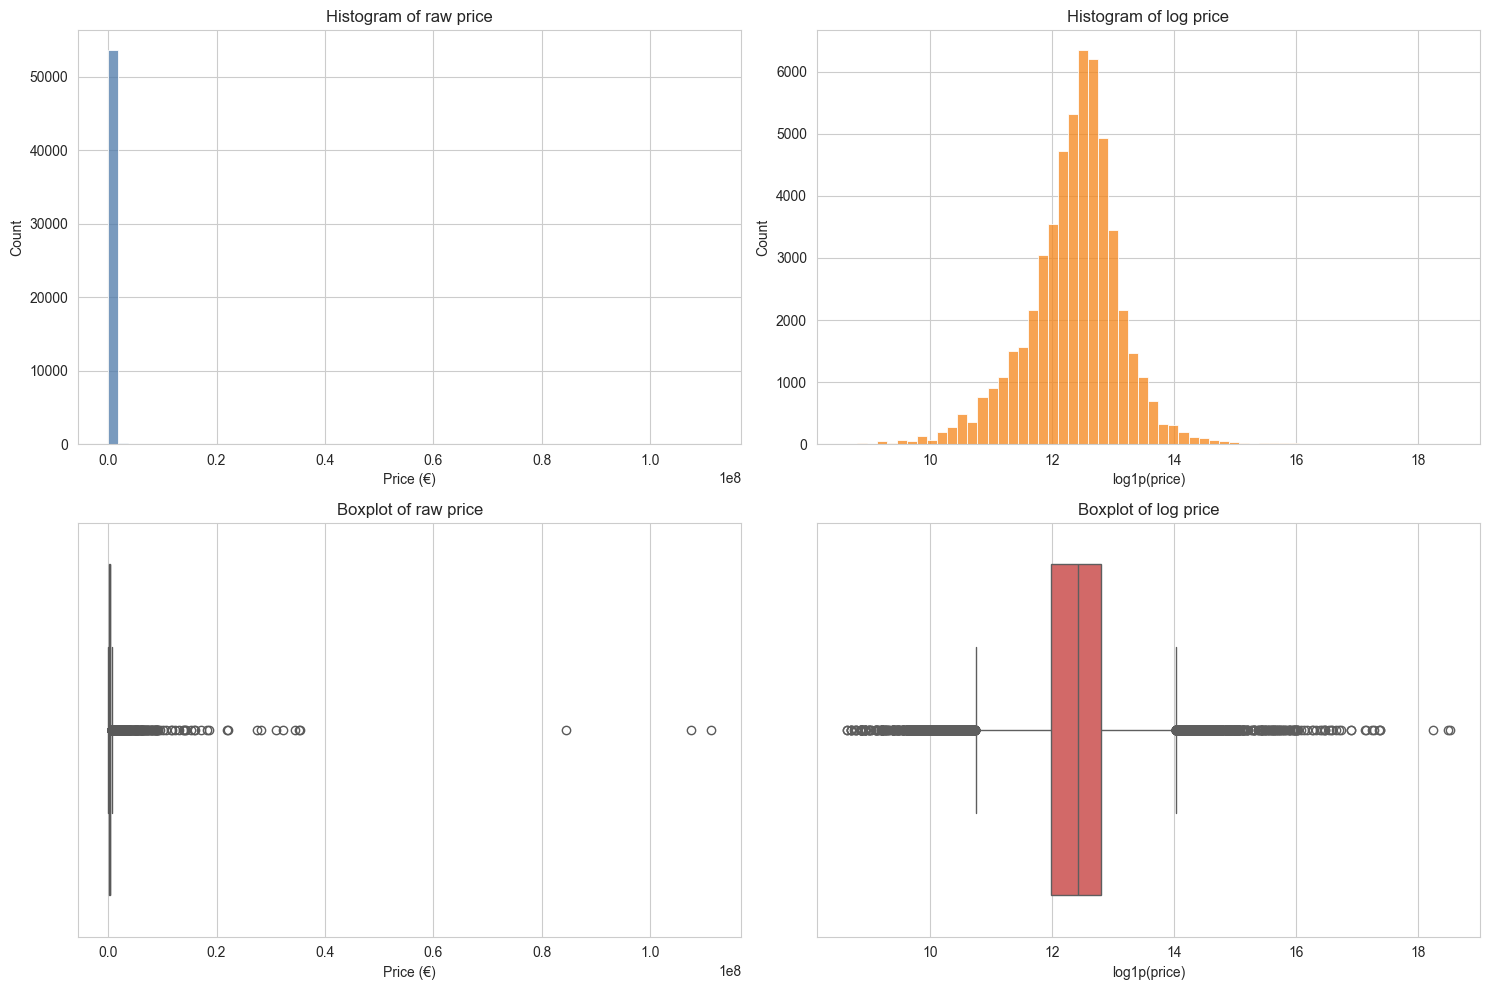

Top 20 highest prices


,Date of Sale (dd/mm/yyyy),County,Eircode_Routing,Address,Price (€),log_price
36854,2022-09-16,Dublin,<NA>,"Davitt PRS Development, Davitt Road, Drimnagh","111,280,172.00",18.53
31932,2021-12-22,Dublin,<NA>,"ST CLARES PARK, HAROLDS CROSS ROAD","107,488,987.00",18.49
23071,2019-06-28,Dublin,D02,"6 HANOVER QUAY, DUBLIN 2","84,420,800.00",18.25
42602,2023-11-29,Dublin,K36,"Malahide Road, Dublin","35,344,317.00",17.38
36620,2022-07-07,Cork,T12,"APARTMENT BG.1, MELBOURN POINT, BISHOPSTOWN","35,178,712.00",17.38
22053,2019-08-01,Dublin,<NA>,"A1-A7 A9 B1-27 C1-40 D1-23, RICHMOND GARDE...","34,515,141.00",17.36
45308,2023-07-07,Dublin,<NA>,"Dundrum View, Ballinteer Road, Dundrum","32,250,000.00",17.29
14498,2018-10-18,Dublin,<NA>,"28 29 30 31 and 32 Gardens Lane, 1 2 2 1/2 an...","31,000,000.00",17.25
29227,2020-10-28,Dublin,<NA>,"Block E2, Dublin Landings","28,193,832.59",17.15
47983,2023-08-31,Dublin,<NA>,"Wilkinson's Brook, Hollystown","27,519,823.79",17.13


Requested percentiles


,price
0.90,"525,000.00"
0.95,"700,000.00"
0.99,"1,452,407.11"
0.99,"2,167,400.88"
1.00,"6,896,229.18"


Extreme price flags


,count
above_99_5pct,271
is_extreme_price,54


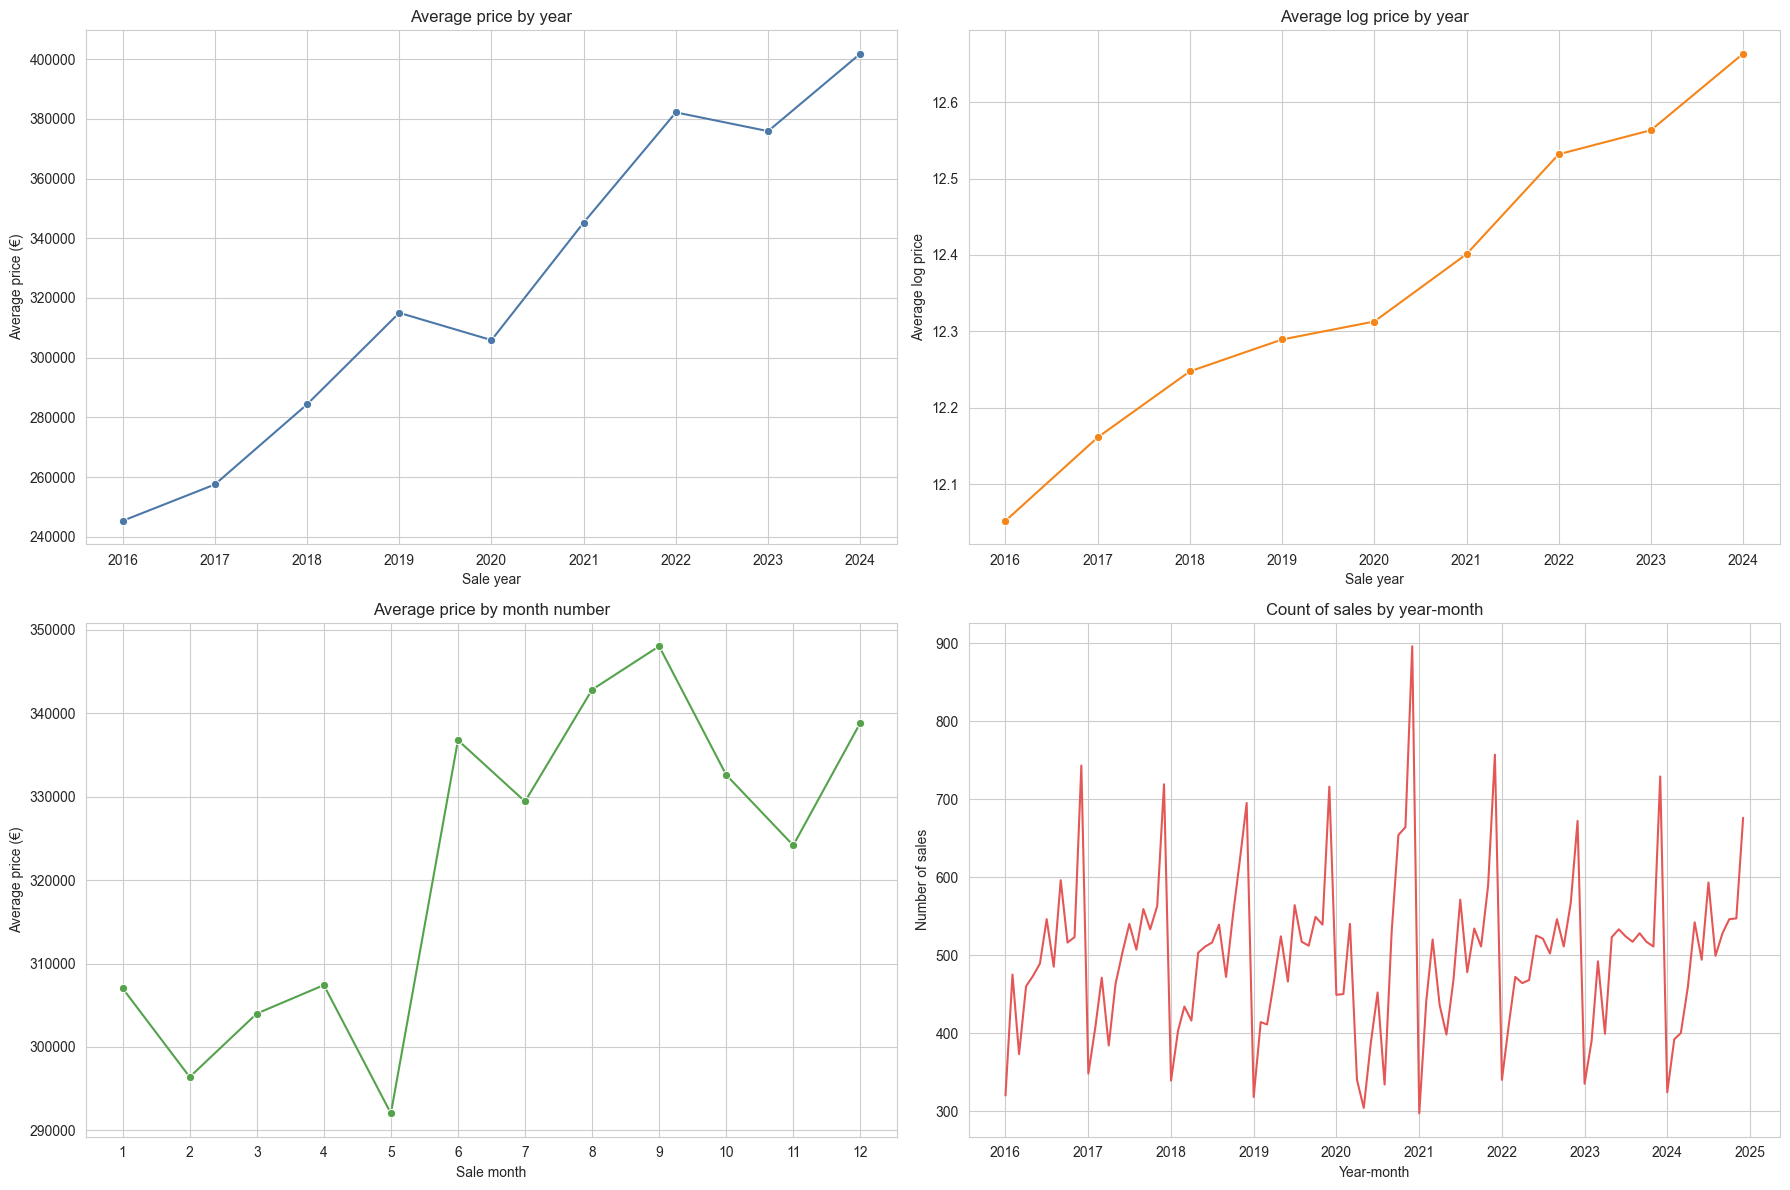

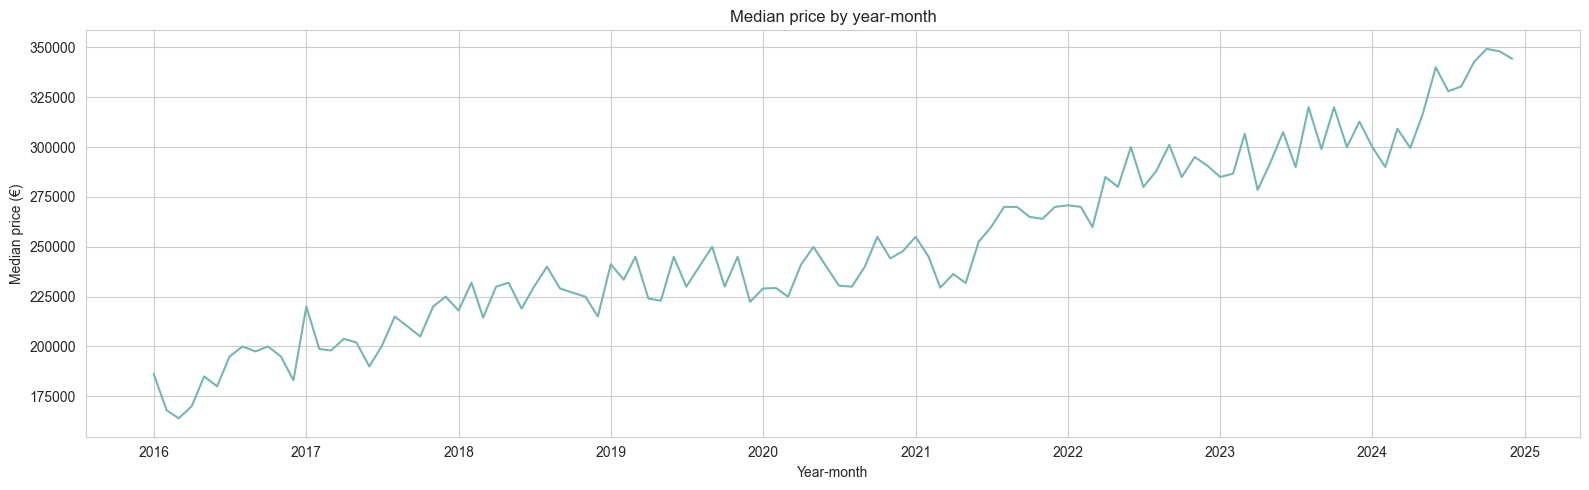

Month-to-month spread in average log price: 0.0970
Start-to-end change in average log price: 0.6110
Interpretation: the long-run time trend is stronger than the within-year seasonal pattern, so year and month index features are likely more important than pure seasonality alone.
Percent missing or unknown in area code: 32.60%
County frequency


,county_clean,count
0,Dublin,16347
1,Cork,5934
2,Kildare,3135
3,Galway,2587
4,Meath,2375
5,Limerick,2011
6,Wexford,1907
7,Wicklow,1843
8,Waterford,1539
9,Louth,1510


Area code frequency


,area_code_clean,count
0,UNKNOWN,17599
1,H91,1409
2,V94,1400
3,D15,1112
4,X91,984
5,A92,710
6,D24,671
7,W91,642
8,D08,604
9,D04,601


Top 20 area codes by count


,area_code_clean,count
0,UNKNOWN,17599
1,H91,1409
2,V94,1400
3,D15,1112
4,X91,984
5,A92,710
6,D24,671
7,W91,642
8,D08,604
9,D04,601


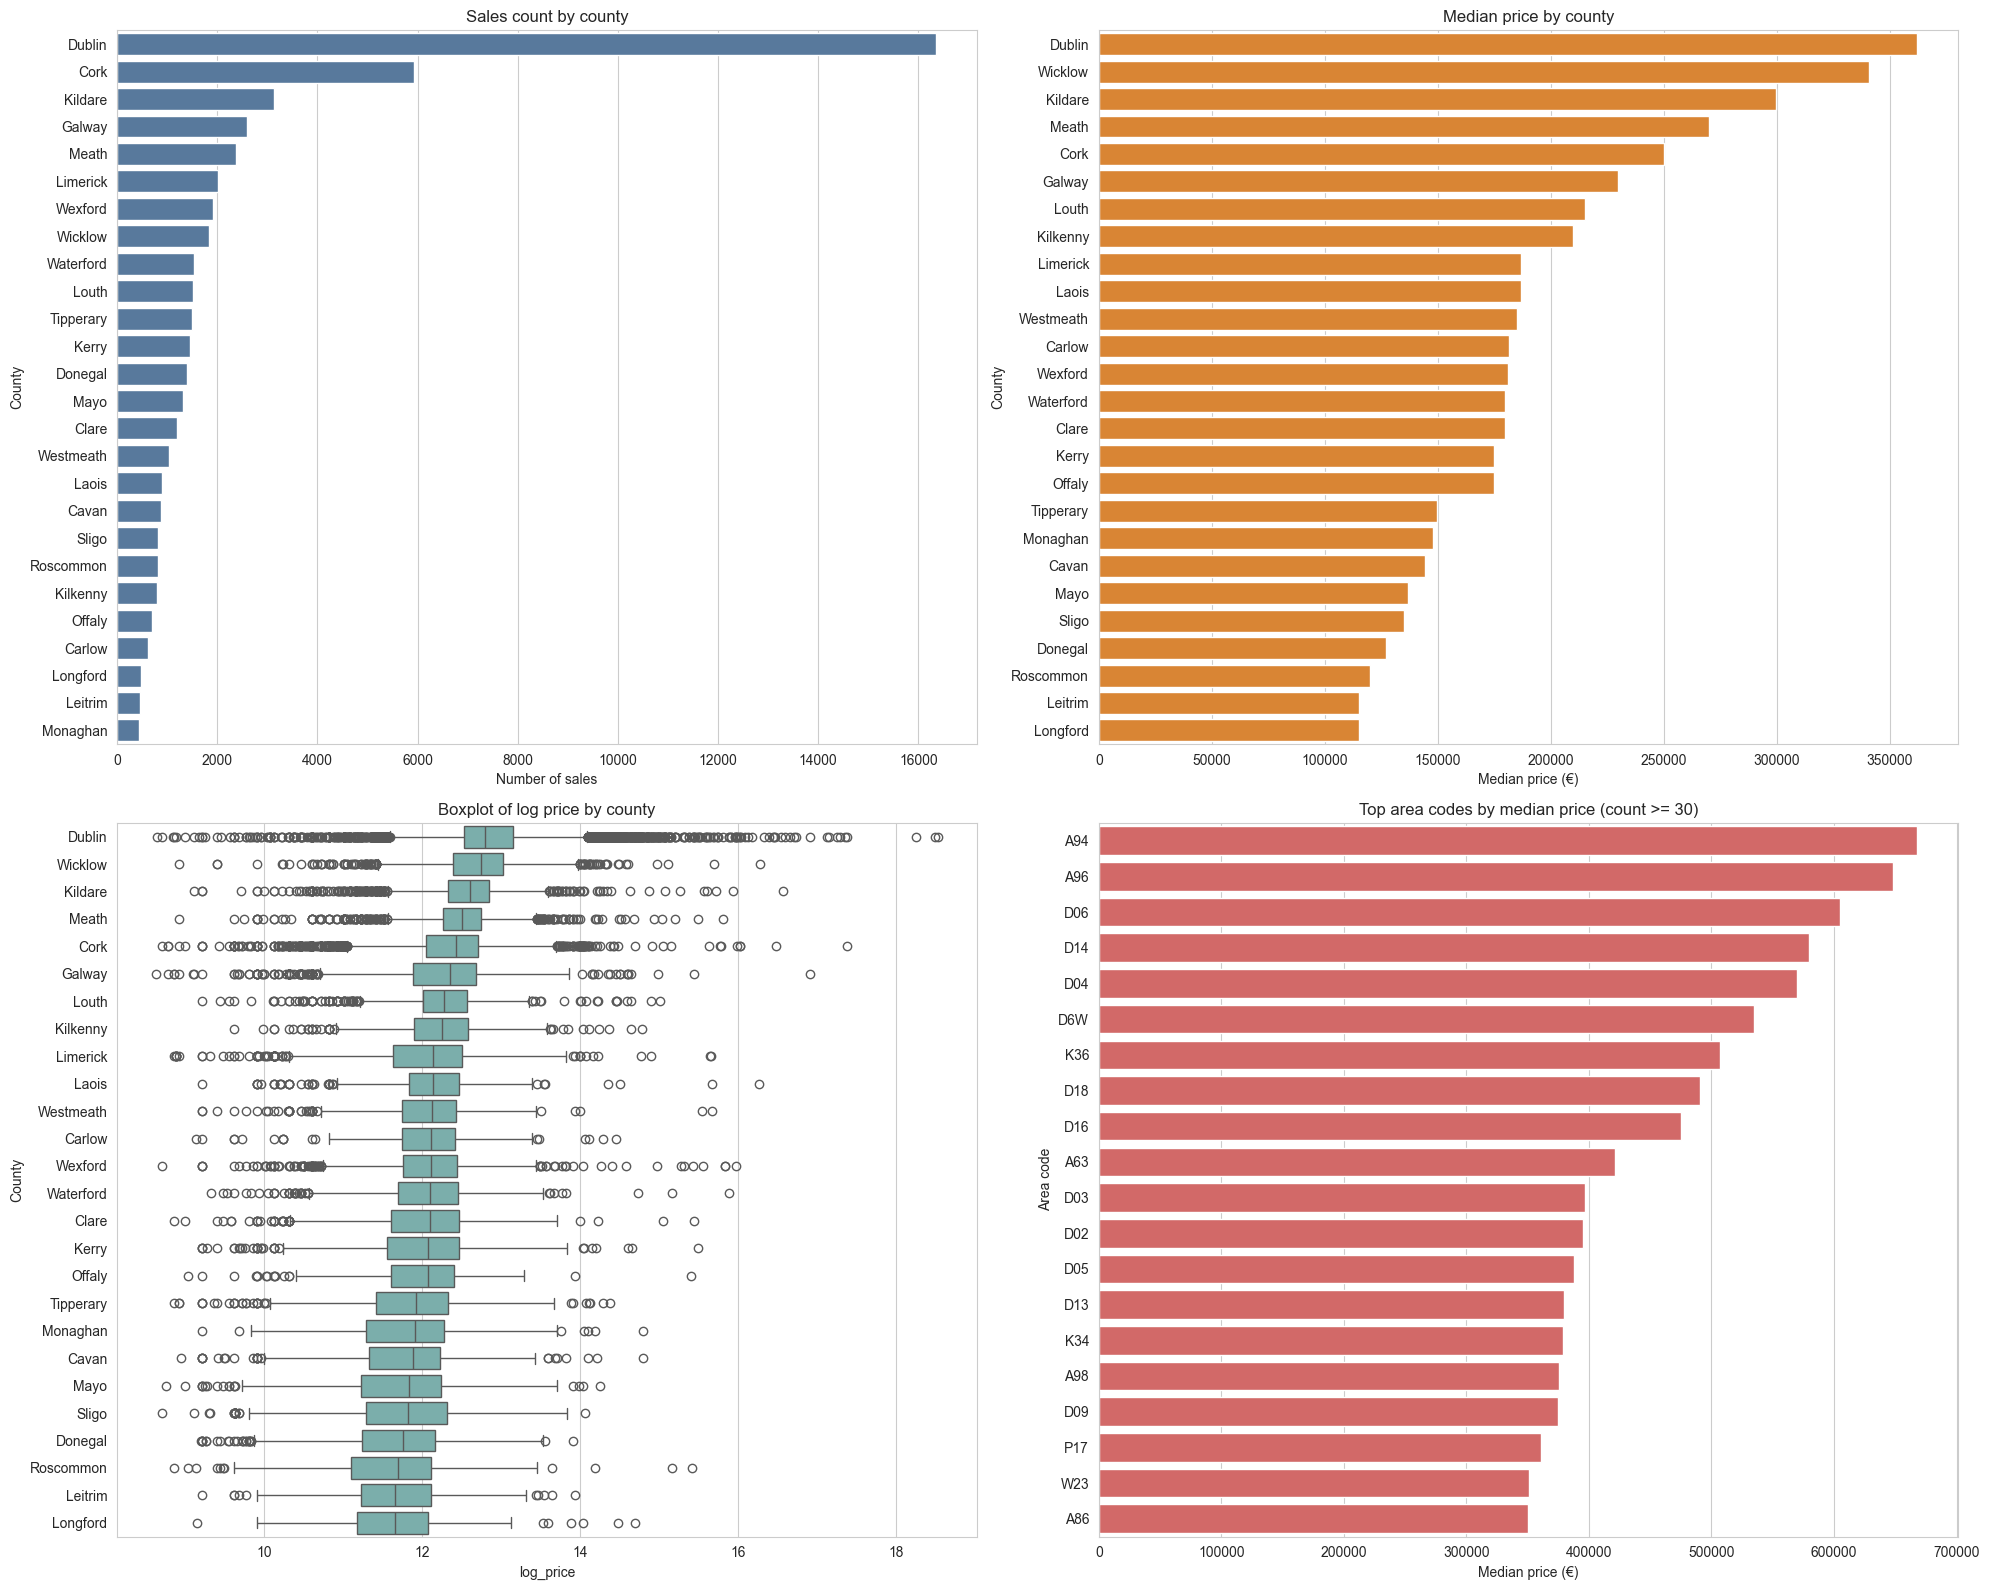

Known vs unknown area-code comparison


,count,mean,median
area_known,,,
Known,36393,12.41,12.47
Unknown,17599,12.25,12.36


Median log-price gap (Known - Unknown area code): 0.1054
Saved cleaned_full to: train_cleaned_full.csv
Saved model_ready to: train_model_ready.csv
cleaned_full shape: (53992, 47)
model_ready shape: (53992, 21)
Train mode: target columns are kept in model_ready when available.
Raw train shape (before raw-signature dedup): (10000, 10)

Columns:
['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (€)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description', 'row_id']

Raw dtypes:
Date of Sale (dd/mm/yyyy)        str
Address                          str
County                           str
Eircode                          str
Price (€)                        str
Not Full Market Price            str
VAT Exclusive                    str
Description of Property          str
Property Size Description    float64
row_id                         int64
dtype: object


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,row_id
0,18/02/2025,"12 ST GABRIELS PLACE, NAAS, KILDARE",Kildare,W91X3HP,"€315,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,1
1,11/12/2025,"KYLEEN EAST, ELPHIN, ROSCOMMOV",Roscommon,NaN,"€200,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,2
2,23/09/2025,"9 SUPPLE PARK SHOPPING CENTRE, DUNSHAUGHLIN, C...",Meath,A85AK06,"€180,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,3
3,29/05/2025,"1 HAYMARKET, DROGHEDA, LOUTH",Louth,A92X627,"€272,500.00",No,No,Second-Hand Dwelling house /Apartment,NaN,4
4,25/09/2025,"32 OAKLEY RD, RANELAGH, DUBLIN 6",Dublin,D06N923,"€2,250,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,5


Converted dtypes:
Date of Sale (dd/mm/yyyy)    datetime64[us]
Address                              string
County                             category
Eircode                            category
Price (€)                           Float64
Not Full Market Price              category
VAT Exclusive                      category
Description of Property            category
Property Size Description          category
row_id                                int64
dtype: object
Missing full Eircode before inference: 25.99%
Missing routing key before inference: 25.99%

Eircode missing % by year (full code):


...

,Description of Property,Is_Second_Hand
0,Second-Hand Dwelling house /Apartment,1
1,Second-Hand Dwelling house /Apartment,1
2,Second-Hand Dwelling house /Apartment,1
3,Second-Hand Dwelling house /Apartment,1
4,Second-Hand Dwelling house /Apartment,1
5,Second-Hand Dwelling house /Apartment,1
6,Second-Hand Dwelling house /Apartment,1
7,Second-Hand Dwelling house /Apartment,1
8,Second-Hand Dwelling house /Apartment,1
9,Second-Hand Dwelling house /Apartment,1


Saved cleaned_full to: test_cleaned_full.csv
Saved model_ready to: test_model_ready.csv
cleaned_full shape: (10000, 44)
model_ready shape: (10000, 21)
Test mode: target columns may be absent, which is expected.

Feature columns used:
['Not Full Market Price', 'county_clean', 'area_code_clean', 'Is_Second_Hand', 'is_apartment_text', 'has_estate_term', 'has_rural_term', 'has_house_number', 'address_token_count', 'county_trailing_6m_median_log_price', 'county_trailing_12m_median_log_price', 'area_trailing_6m_median_log_price', 'area_trailing_12m_median_log_price', 'County_New_Dwellings', 'Area_New_Dwellings', 'Mortgage Interest Rate', 'Population', 'sale_year', 'sale_month']

Train split
Fit rows: 47992
Validation rows: 6000
Validation starts at: 2023-12-31
0:	learn: 0.7613823	test: 0.7467478	best: 0.7467478 (0)	total: 68.4ms	remaining: 4m 33s
200:	learn: 0.5549280	test: 0.5248702	best: 0.5248702 (200)	total: 1.93s	remaining: 36.6s
400:	learn: 0.5420928	test: 0.5186095	best: 0.5186095 (40

,Date of Sale (dd/mm/yyyy),Address,County,Price (€),predicted_price,abs_error,pct_error
0,2025-02-18,"12 ST GABRIELS PLACE, NAAS, KILDARE",Kildare,"315,000.00","350,531.36","35,531.36",11.28
1,2025-12-11,"KYLEEN EAST, ELPHIN, ROSCOMMOV",Roscommon,"200,000.00","128,231.10","71,768.90",35.88
2,2025-09-23,"9 SUPPLE PARK SHOPPING CENTRE, DUNSHAUGHLIN, C...",Meath,"180,000.00","226,849.17","46,849.17",26.03
3,2025-05-29,"1 HAYMARKET, DROGHEDA, LOUTH",Louth,"272,500.00","286,259.41","13,759.41",5.05
4,2025-09-25,"32 OAKLEY RD, RANELAGH, DUBLIN 6",Dublin,"2,250,000.00","322,166.28","1,927,833.72",85.68
5,2025-06-12,"50 SNOWDROP WALK, DARNDALE, DUBLIN 17",Dublin,"255,000.00","295,826.06","40,826.06",16.01
6,2025-02-14,"48 ASHGROVE, GLENCAIRIN, DOORAOOYLE",Limerick,"450,000.00","266,369.23","183,630.77",40.81
7,2025-09-08,"CLOONRANE, CURRY, TUBBERCURRY",Sligo,"350,000.00","167,444.66","182,555.34",52.16
8,2025-10-28,"86 GRANGE PARK CRESCENT, RAHENY, DUBLIN 5",Dublin,"515,000.00","305,585.29","209,414.71",40.66
9,2025-07-22,"7 MOUNT HENRY CLOSE, KILLENARD, PORTARLINGTON",Laois,"485,000.00","251,056.72","233,943.28",48.24



Worst 20 absolute errors


,Date of Sale (dd/mm/yyyy),Address,County,Price (€),predicted_price,abs_error,pct_error
5718,2025-04-11,"Site for Blocks B and C, Woodbrook, Shankill",Dublin,"127,920,140.00","4,091,014.83","123,829,125.17",96.80
7280,2025-08-28,"1 SHACKLETON EXCHANGE, SHACKLETON DRIVE, LUCAN",Dublin,"43,185,177.00","295,416.93","42,889,760.07",99.32
9588,2025-06-06,"Apartments 1-95 (inclusive), The Paddocks Bal...",Dublin,"34,323,696.92","921,601.34","33,402,095.58",97.31
5475,2025-11-07,"Swuite Grangegorman, 13 - 18 Grangegorman Lowe...",Dublin,"20,137,614.68","473,630.75","19,663,983.93",97.65
1161,2025-12-04,"1-20 Ash House 1-20 Hazel House, 7-12 and 14-...",Meath,"20,389,427.30","1,350,715.67","19,038,711.63",93.38
8754,2025-04-30,"CLONBEALY, NEWPORT, TIPPERARY",Tipperary,"14,050,971.00","154,195.03","13,896,775.97",98.90
7616,2025-10-14,"APT 1 2 BRIDGE ST, 2 BRIDGE ST, CLONGRIFFIN",Dublin,"12,857,430.37","223,488.53","12,633,941.84",98.26
4621,2025-12-05,"Teach San Labhras, St Laurence House, Ballyfermot",Dublin,"12,275,801.10","1,025,239.16","11,250,561.94",91.65
5847,2025-09-29,"1 PORTVIEW, THORNCASTLE ST, RINGSEND",Dublin,"11,440,000.00","339,162.05","11,100,837.95",97.04
5045,2025-11-28,"21-53 Hartys Park, Crushrod Lane, Drogheda",Louth,"10,879,351.30","505,325.55","10,374,025.75",95.36


In [43]:
DATE_COL = 'Date of Sale (dd/mm/yyyy)'
PRICE_COL = 'Price (€)'


def prepare_catboost_frame(df, feature_cols, categorical_cols):
    out = df[feature_cols].copy()

    for col in categorical_cols:
        if col in out.columns:
            out[col] = out[col].astype('string').fillna('MISSING')

    numeric_cols = [col for col in feature_cols if col not in categorical_cols]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')

    return out


def print_regression_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = (np.abs((y_true - y_pred) / y_true).replace([np.inf, -np.inf], np.nan).dropna().mean()) * 100

    print(f'\n{label}')
    print(f'RMSE: {rmse:,.2f}')
    print(f'MAE : {mae:,.2f}')
    print(f'R^2 : {r2:.4f}')
    print(f'MAPE: {mape:.2f}%')


if __name__ == "__main__":
    # -------------------------
    # 1. Train preprocessing
    # -------------------------
    df_raw_train = load_and_inspect_dataset("ppr-group-22312913-train.csv", delete_dup=True)
    df_dqr_train = clean_and_cast_dtypes(df_raw_train)
    run_quality_checks(df_dqr_train)
    df_dqr_train = area_code_inference(df_dqr_train)
    df_dqr_train = second_hand_inference(df_dqr_train)
    df_dqr_train = statistical_report(df_dqr_train)
    df_dqr_train = step7_add_features(df_dqr_train, is_train=True)
    df_dqr_train = step8_add_external_features(df_dqr_train)

    train_exports = step9_build_final_exports(
        df_dqr_train,
        is_train=True,
        save=True,
        cleaned_full_path='train_cleaned_full.csv',
        model_ready_path='train_model_ready.csv',
    )

    df_train_cleaned_full = train_exports['cleaned_full']
    df_train_model_ready = train_exports['model_ready']

    # -------------------------
    # 2. Test preprocessing
    # -------------------------
    # Keep all rows in test so evaluation stays aligned to the supplied file.
    df_raw_test = load_and_inspect_dataset("ppr-group-22312913-test.csv", delete_dup=False)
    df_dqr_test = clean_and_cast_dtypes(df_raw_test)
    df_dqr_test = area_code_inference(df_dqr_test)
    df_dqr_test = second_hand_inference(df_dqr_test)

    # Do NOT run statistical_report on test before modelling.
    # It creates target-derived columns and would leak test price information.
    df_dqr_test = step7_add_features(
        df_dqr_test,
        history_df=df_dqr_train,
        is_train=False,
    )
    df_dqr_test = step8_add_external_features(df_dqr_test)

    # Add the true log target only after feature generation, for scoring only.
    df_dqr_test[PRICE_COL] = pd.to_numeric(df_dqr_test[PRICE_COL], errors='coerce')
    df_dqr_test['log_price'] = np.log1p(df_dqr_test[PRICE_COL])

    test_exports = step9_build_final_exports(
        df_dqr_test,
        is_train=False,
        save=True,
        cleaned_full_path='test_cleaned_full.csv',
        model_ready_path='test_model_ready.csv',
    )

    df_test_cleaned_full = test_exports['cleaned_full']
    df_test_model_ready = test_exports['model_ready']

    # -------------------------
    # 3. Define modelling columns
    # -------------------------
    categorical_cols = [
        'Not Full Market Price',
        'county_clean',
        'area_code_clean',
    ]

    numeric_cols = [
        'Is_Second_Hand',
        'is_apartment_text',
        'has_estate_term',
        'has_rural_term',
        'has_house_number',
        'address_token_count',
        'county_trailing_6m_median_log_price',
        'county_trailing_12m_median_log_price',
        'area_trailing_6m_median_log_price',
        'area_trailing_12m_median_log_price',
        'County_New_Dwellings',
        'Area_New_Dwellings',
        'Mortgage Interest Rate',
        'Population',
        'sale_year',
        'sale_month',
    ]

    feature_cols = [
        col for col in (categorical_cols + numeric_cols)
        if col in df_train_model_ready.columns and col in df_test_model_ready.columns
    ]
    categorical_cols = [col for col in categorical_cols if col in feature_cols]

    print('\nFeature columns used:')
    print(feature_cols)

    # -------------------------
    # 4. Internal time-based validation inside train
    # -------------------------
    train_dates = df_train_cleaned_full[[DATE_COL]].copy()
    train_dates[DATE_COL] = pd.to_datetime(train_dates[DATE_COL], errors='coerce')

    train_model = df_train_model_ready.copy()
    train_model = train_model.join(train_dates)

    train_model = train_model.dropna(subset=[DATE_COL, 'log_price']).copy()

    validation_start = train_model[DATE_COL].max() - pd.DateOffset(months=12)

    fit_df = train_model.loc[train_model[DATE_COL] < validation_start].copy()
    val_df = train_model.loc[train_model[DATE_COL] >= validation_start].copy()

    print('\nTrain split')
    print('Fit rows:', fit_df.shape[0])
    print('Validation rows:', val_df.shape[0])
    print('Validation starts at:', validation_start.date())

    X_fit = prepare_catboost_frame(fit_df, feature_cols, categorical_cols)
    y_fit = pd.to_numeric(fit_df['log_price'], errors='coerce')

    X_val = prepare_catboost_frame(val_df, feature_cols, categorical_cols)
    y_val = pd.to_numeric(val_df['log_price'], errors='coerce')

    # -------------------------
    # 5. Tune stopping point on internal validation only
    # -------------------------
    tuned_model = CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        iterations=4000,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=5,
        random_seed=42,
        early_stopping_rounds=200,
        verbose=200,
    )

    tuned_model.fit(
        X_fit,
        y_fit,
        cat_features=categorical_cols,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )

    best_iteration = tuned_model.get_best_iteration()
    if best_iteration is None or best_iteration <= 0:
        best_iteration = 4000

    print('\nBest iteration from internal validation:', best_iteration)

    # -------------------------
    # 6. Refit on full train
    # -------------------------
    full_train = df_train_model_ready.copy()
    full_train = full_train.dropna(subset=['log_price']).copy()

    X_train = prepare_catboost_frame(full_train, feature_cols, categorical_cols)
    y_train = pd.to_numeric(full_train['log_price'], errors='coerce')

    final_model = CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        iterations=int(best_iteration),
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=5,
        random_seed=42,
        verbose=200,
    )

    final_model.fit(
        X_train,
        y_train,
        cat_features=categorical_cols,
    )

    # -------------------------
    # 7. Evaluate on the provided 2025 test set
    # -------------------------
    test_model = df_test_model_ready.copy()
    test_model = test_model.dropna(subset=[PRICE_COL]).copy()

    X_test = prepare_catboost_frame(test_model, feature_cols, categorical_cols)
    y_test_price = pd.to_numeric(test_model[PRICE_COL], errors='coerce')
    y_test_log = np.log1p(y_test_price)

    pred_test_log = final_model.predict(X_test)
    pred_test_price = np.expm1(pred_test_log)

    # Metrics on the scale the model was trained on
    print_regression_metrics(y_test_log, pred_test_log, 'Test metrics on log-price scale')

    # Metrics on actual euro prices
    print_regression_metrics(y_test_price, pred_test_price, 'Test metrics on euro-price scale')

    # Median-price baseline for comparison
    baseline_log = np.repeat(y_train.median(), len(y_test_log))
    baseline_price = np.expm1(baseline_log)

    print_regression_metrics(y_test_log, baseline_log, 'Baseline test metrics on log-price scale')
    print_regression_metrics(y_test_price, baseline_price, 'Baseline test metrics on euro-price scale')

    # Show a quick sample of predictions
    comparison = df_test_cleaned_full[[DATE_COL, 'Address', 'County', PRICE_COL]].copy()
    comparison = comparison.loc[test_model.index].copy()
    comparison['predicted_price'] = pred_test_price
    comparison['abs_error'] = (comparison[PRICE_COL] - comparison['predicted_price']).abs()
    comparison['pct_error'] = comparison['abs_error'] / comparison[PRICE_COL] * 100

    print('\nSample predictions')
    display(comparison.head(20))

    print('\nWorst 20 absolute errors')
    display(comparison.sort_values('abs_error', ascending=False).head(20))

In [44]:
# Full dataframe shape
print('Shape:', df_dqr_train.shape)

# Show all column names
print('\nAll columns:')
for col in df_dqr_train.columns:
    print(col)

# Show first few rows with all columns visible
display(df_dqr_train.head(10))

# Summary of all columns
display(df_dqr_train.info())

# Numeric summary
display(df_dqr_train.describe(include=[np.number]).T)

# Categorical / text summary
display(df_dqr_train.describe(include=['object', 'string', 'category']).T)

# Missing values summary
missing_summary = pd.DataFrame({
    'missing_count': df_dqr_train.isna().sum(),
    'missing_pct': (df_dqr_train.isna().mean() * 100).round(2),
    'dtype': df_dqr_train.dtypes.astype(str),
})
display(missing_summary.sort_values('missing_pct', ascending=False))

Shape: (53992, 47)

All columns:
Date of Sale (dd/mm/yyyy)
Address
County
Eircode
Price (€)
Not Full Market Price
VAT Exclusive
Description of Property
Property Size Description
row_id
Year
Month
Eircode_Routing
Address_clean
Eircode_Routing_Inferred
Is_Second_Hand
log_price
above_99_5pct
is_extreme_price
sale_year
sale_month
sale_period
sale_month_start
county_clean
area_code_clean
area_code_missing
address_text
is_apartment_text
has_estate_term
has_rural_term
has_house_number
address_token_count
county_trailing_6m_median_log_price
county_trailing_12m_median_log_price
area_trailing_6m_median_log_price
area_trailing_12m_median_log_price
Quarter
Area Code
County_Clean
County_Area
Population_Year
Dwellings_Year
Dwellings_Quarter
County_New_Dwellings
Area_New_Dwellings
Mortgage Interest Rate
Population


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,row_id,Year,Month,Eircode_Routing,Address_clean,Eircode_Routing_Inferred,Is_Second_Hand,log_price,above_99_5pct,is_extreme_price,sale_year,sale_month,sale_period,sale_month_start,county_clean,area_code_clean,area_code_missing,address_text,is_apartment_text,has_estate_term,has_rural_term,has_house_number,address_token_count,county_trailing_6m_median_log_price,county_trailing_12m_median_log_price,area_trailing_6m_median_log_price,area_trailing_12m_median_log_price,Quarter,Area Code,County_Clean,County_Area,Population_Year,Dwellings_Year,Dwellings_Quarter,County_New_Dwellings,Area_New_Dwellings,Mortgage Interest Rate,Population
0,2016-04-01,"7 MARLTON DEMESNE, DEMESNE, WICKLOW",Wicklow,NaN,"450,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,1,2016,4,<NA>,7 MARLTON DEMESNE DEMESNE WICKLOW,<NA>,1,13.02,0,0,2016,4,2016-04,2016-04-01,Wicklow,UNKNOWN,1,"7 MARLTON DEMESNE, DEMESNE, WICKLOW",0,0,0,1,5,12.47,NaN,NaN,NaN,2,<NA>,Wicklow,<NA>,2015,2016,1,49.00,NaN,102.10,NaN
1,2016-09-15,"90 SLIEVE RUA DR, KILMACUD, BLACKROCK",Dublin,NaN,"560,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,2,2016,9,A94,90 SLIEVE RUA DR KILMACUD BLACKROCK,A94,1,13.24,0,0,2016,9,2016-09,2016-09-01,Dublin,A94,0,"90 SLIEVE RUA DR, KILMACUD, BLACKROCK",0,0,0,1,6,12.61,12.59,13.37,13.24,3,A94,Dublin,Dublin,2015,2016,2,843.00,3.00,99.90,NaN
2,2016-12-21,"APT. 1 ABOVE BERGERACS, MAIN STREET, ROASREA",Tipperary,NaN,"44,200.00",No,No,Second-Hand Dwelling house /Apartment,NaN,3,2016,12,<NA>,APT 1 ABOVE BERGERACS MAIN STREET ROASREA,<NA>,1,10.70,0,0,2016,12,2016-12,2016-12-01,Tipperary,UNKNOWN,1,"APT. 1 ABOVE BERGERACS, MAIN STREET, ROASREA",1,0,0,1,7,11.44,11.41,NaN,NaN,4,<NA>,Tipperary,<NA>,2015,2016,3,43.00,NaN,100.00,NaN
3,2016-08-17,"6 MARIEMOUNT GROVE, BALLINAMORE, COUNTY LEITRIM",Leitrim,NaN,"65,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,4,2016,8,<NA>,6 MARIEMOUNT GROVE BALLINAMORE COUNTY LEITRIM,<NA>,1,11.08,0,0,2016,8,2016-08,2016-08-01,Leitrim,UNKNOWN,1,"6 MARIEMOUNT GROVE, BALLINAMORE, COUNTY LEITRIM",0,0,0,1,6,11.31,11.35,NaN,NaN,3,<NA>,Leitrim,<NA>,2015,2016,2,17.00,NaN,100.30,NaN
4,2016-04-19,"THE GLADE, TYMULLEN, MONASTERBOICE",Louth,NaN,"400,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,5,2016,4,<NA>,THE GLADE TYMULLEN MONASTERBOICE,<NA>,1,12.90,0,0,2016,4,2016-04,2016-04-01,Louth,UNKNOWN,1,"THE GLADE, TYMULLEN, MONASTERBOICE",0,0,0,0,4,11.92,NaN,NaN,NaN,2,<NA>,Louth,<NA>,2015,2016,1,22.00,NaN,102.10,NaN
5,2016-07-05,"SILVERDALE HOUSE, CASTLEKNOCK RD, DUBLIN",Dublin,NaN,"1,320,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,6,2016,7,<NA>,SILVERDALE HOUSE CASTLEKNOCK RD DUBLIN,<NA>,1,14.09,0,0,2016,7,2016-07,2016-07-01,Dublin,UNKNOWN,1,"SILVERDALE HOUSE, CASTLEKNOCK RD, DUBLIN",0,0,1,0,5,12.58,12.58,NaN,NaN,3,<NA>,Dublin,<NA>,2015,2016,2,843.00,NaN,100.30,NaN
6,2016-02-26,"11 CLUAIN CREGG, CARRICK ON SUIR, TIPPERARY",Tipperary,NaN,"235,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,7,2016,2,E32,11 CLUAIN CREGG CARRICK ON SUIR TIPPERARY,E32,1,12.37,0,0,2016,2,2016-02,2016-02-01,Tipperary,E32,0,"11 CLUAIN CREGG, CARRICK ON SUIR, TIPPERARY",0,0,0,1,7,NaN,NaN,NaN,NaN,1,E32,Tipperary,Tipperary,2015,2015,4,NaN,NaN,103.40,NaN
7,2016-11-30,"1 HAZELDEAN, BLACKWATER, ENNISCORTHY",Wexford,NaN,"189,185.02",No,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...,8,2016,11,Y21,1 HAZELDEAN BLACKWATER ENNISCORTHY,Y21,0,12.15,0,0,2016,11,2016-11,2016-11-01,Wexford,Y21,0,"1 HAZELDEAN, BLACKWATER, ENNISCORTHY",0,0,0,1,4,11.81,11.88,11.66,11.65,4,Y21,Wexford,Wexford,2015,2016,3,45.00,15.00,99.90,NaN
8,2016-06-08,"4 WATERSIDE, CASTLEHEIGHTS, KILMONEY RD",Cork,NaN,"226,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,9,2016,6,<NA>,4 WATERSIDE CASTLEHEIGHTS KILMONEY RD,<NA>,1,12.33,0,0,2016,6,2016-06,2016-06-01,Cork,UNKNOWN,1,"4 WATERSIDE, 

<class 'pandas.DataFrame'>
RangeIndex: 53992 entries, 0 to 53991
Data columns (total 47 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Date of Sale (dd/mm/yyyy)             53992 non-null  datetime64[us]
 1   Address                               53992 non-null  string        
 2   County                                53992 non-null  category      
 3   Eircode                               16901 non-null  category      
 4   Price (€)                             53992 non-null  Float64       
 5   Not Full Market Price                 53992 non-null  category      
 6   VAT Exclusive                         53992 non-null  category      
 7   Description of Property               53992 non-null  category      
 8   Property Size Description             2775 non-null   category      
 9   row_id                                53992 non-null  int64         
 10  Year     

None

,count,mean,std,min,25%,50%,75%,max
Price (€),"53,992.00","323,710.69","950,626.38","5,586.84","159,000.00","250,000.00","362,500.00","111,280,172.00"
row_id,"53,992.00","27,000.83","15,588.73",1.00,"13,500.75","27,002.50","40,500.25","54,000.00"
Year,"53,992.00","2,020.00",2.58,"2,016.00","2,018.00","2,020.00","2,022.00","2,024.00"
Month,"53,992.00",7.08,3.45,1.00,4.00,7.00,10.00,12.00
Is_Second_Hand,"53,992.00",0.82,0.38,0.00,1.00,1.00,1.00,1.00
log_price,"53,992.00",12.36,0.77,8.63,11.98,12.43,12.80,18.53
above_99_5pct,"53,992.00",0.01,0.07,0.00,0.00,0.00,0.00,1.00
is_extreme_price,"53,992.00",0.00,0.03,0.00,0.00,0.00,0.00,1.00
sale_year,"53,992.00","2,020.00",2.58,"2,016.00","2,018.00","2,020.00","2,022.00","2,024.00"
sale_month,"53,992.00",7.08,3.45,1.00,4.00,7.00,10.00,12.00


,count,unique,top,freq
Address,53992,53315,"TURLOUGH RD, CASTLEBAR, MAYO",4
County,53992,26,Dublin,16347
Eircode,16901,16849,A92D535,2
Not Full Market Price,53992,2,No,51182
VAT Exclusive,53992,2,No,44537
Description of Property,53992,2,Second-Hand Dwelling house /Apartment,44404
Property Size Description,2775,4,greater than or equal to 38 sq metres and less...,2039
Eircode_Routing,36393,153,H91,1409
Address_clean,53992,53266,TURLOUGH RD CASTLEBAR MAYO,4
Eircode_Routing_Inferred,29557,126,H91,1302


,missing_count,missing_pct,dtype
Property Size Description,51217,94.86,category
Eircode,37091,68.70,category
Eircode_Routing_Inferred,24435,45.26,object
area_trailing_12m_median_log_price,20580,38.12,float64
County_Area,19948,36.95,string
area_trailing_6m_median_log_price,19627,36.35,float64
Area_New_Dwellings,18236,33.78,float64
Eircode_Routing,17599,32.60,string
Area Code,17599,32.60,string
Population,11998,22.22,float64
